#### Arquivo: 01_pipeline_preparacao_dados.ipynb

<div style="text-align:center;">
    <img src="https://www.fiemg.com.br/fiemg/wp-content/uploads/sites/10/2023/02/fiemg.png" width="350">
</div>

<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:800;
  color:#0B2D4D;
  background:#BFE9FF;
  font-size:30px;
  padding:16px 18px;
  border-radius:14px;
  margin:14px 0 10px 0;
">
  Projeto de Engenharia de Dados
</div>

<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#0B2D4D;
  background:#E6F6FF;
  font-size:18px;
  padding:12px 16px;
  border-radius:12px;
  margin:0 0 14px 0;
">
  Pipeline Medallion (Bronze → Silver → Gold) com auditoria, quarentena e persistência em SQLite.
</div>

## 1. Visão Geral

Pipeline end-to-end para transformar dados transacionais brutos em uma **base analítica confiável (Gold)**, aplicando **regras de negócio**, **padronização de schema**, **validações de qualidade**, **integridade referencial** e **reconciliação financeira** com tolerância híbrida.

---

## 2. Arquitetura (Medallion)

### Bronze (Raw)

* Snapshot fiel dos arquivos de entrada (sem transformação)
* Base para rastreabilidade e reprocessamento

### Silver (Clean)

* Harmonização de colunas e tipos (datas/numéricos)
* Normalização de status
* Deduplicação determinística
* Flags de qualidade + quarentena de registros inválidos
* Integridade referencial (órfãos order/product)
* Cálculo de GMV bruto e líquido (com cap de desconto)

### Gold (Analytical)

* Consolidação final para consumo analítico/BI
* Reconciliação: **GMV líquido × pagamentos × total_value**
* Agregações (ex.: GMV por seller/mês)

---

## 3. Controles de Qualidade

* **Schema enforcement** + validação estrutural **fail-fast**
* **Deduplicação determinística**
* **Integridade referencial** (detecção de órfãos)
* **Cap de desconto** (evita net negativo)
* **Reconciliação híbrida**: `max(abs_tol, rel_tol * |gmv_net|)`
* **Data tests** com thresholds configuráveis (STRICT opcional)
* **Audit trail** estruturado + **quarentena** para investigação

---

## 4. Resultados / Executive Output

### 4.1 Volume Processado

* **80.000** pedidos analisados
* **68.050** pedidos válidos para métricas
* **60.077** pedidos concluídos (**Base Gold**)

### 4.2 Qualidade Financeira

* **14,94%** de pagamentos descartados (não efetivados)
* **100%** de reconciliação na **Base Gold**
* Divergência ≈ **0** (residual de ponto flutuante)

### 4.3 Métricas de Negócio

* **GMV Líquido (Base Gold): R$ 949,9 milhões**
* **Ticket Médio: R$ 15.812,52**
* **120** sellers ativos

### 4.4 Data Health Score

**100/100 — base final íntegra dentro dos critérios definidos.**

* **0% órfãos** (integridade referencial preservada)
* **0% divergências acima do threshold** (tolerância híbrida abs + rel)
* **0% falhas estruturais** (sem violações críticas)

---

## 5. Painel Final (Gold) — O que este bloco entrega

* Contagens por regras de “validade”
* GMV bruto e líquido (**geral** vs **Base Gold**)
* Ticket médio (por base e por pedidos pagos)
* Estatísticas de pagamentos e reconciliação
* **Data Health Score (0–100)** com penalizações por taxa de problemas

**Nota:**

* **GERAL** = tudo após limpeza (Silver).
* **BASE GOLD** = apenas pedidos presentes em `base_orders`.


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#0B2D4D;
  background:#BFE9FF;
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  1 - Setup do Projeto
</div>

#### 1.1 Descoberta automática da raiz do repositório e definição de paths

In [1]:
# Bloco — Descoberta automática da raiz do repositório e definição de paths (PROJECT_ROOT)
#
# Objetivo:
#   Garantir que caminhos de leitura/escrita (data/, outputs/, sql/) funcionem
#   independente de onde o notebook foi aberto (raiz do repo ou /notebooks).
#
# Estratégia:
#   1) Se estivermos dentro de uma pasta "notebooks", assume que a raiz é o pai.
#   2) Caso contrário, sobe diretórios procurando "marcadores" do repo:
#        - README.md, .git, pyproject.toml, requirements.txt, setup.cfg
#   3) Se não encontrar, usa o diretório inicial como fallback.

from pathlib import Path

def _find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()

    # Caso típico: notebook aberto em <repo>/notebooks
    if p.name.lower() == "notebooks":
        return p.parent

    markers = {"README.md", ".git", "pyproject.toml", "requirements.txt", "setup.cfg"}

    for _ in range(8):  # um pouco mais de folga
        if any((p / m).exists() for m in markers):
            return p
        p = p.parent

    return (start or Path.cwd()).resolve()

PROJECT_ROOT = _find_project_root()
print("PROJECT_ROOT =", PROJECT_ROOT)

# Exemplos:
# DATA_DIR = PROJECT_ROOT / "data"
# RAW_DIR = DATA_DIR / "raw"
# PROCESSED_DIR = DATA_DIR / "processed"
# OUTPUTS_DIR = PROJECT_ROOT / "outputs"


PROJECT_ROOT = C:\github_repo\marketplace-b2b-data-pipeline


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#0B2D4D;
  background:#BFE9FF;
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  2 - Observabilidade e Execução
</div>

#### 2.1 Instrumentação automática de tempo de execução por célula

In [2]:
%%time
# Bloco 01 — Instrumentação de tempo (profiling simples) para o notebook
#
# Objetivo:
# - Medir o tempo total desde o início da execução do notebook
# - Medir o tempo de blocos/células específicos via um context manager
# - Guardar os resultados em uma lista para posterior inspeção/relatório

import time
from contextlib import contextmanager

# Marca o início do "tempo total" do notebook.
# perf_counter() é recomendado para medições de performance (alta resolução),
# pois mede tempo monotônico (não sofre com ajustes do relógio do sistema).
__nb_start_time__ = time.perf_counter()

# Estrutura para armazenar as medições parciais.
# Cada item será um dicionário com:
# - cell_index: índice/ordem da célula/bloco (inteiro)
# - label: rótulo descritivo do que foi medido (string)
# - seconds: duração em segundos (float)
__cell_timings = []  # list[dict[str, Any]]

@contextmanager
def __time_block(cell_index: int, label: str):
    """
    Context manager para medir a duração de um trecho de código.

    Parâmetros:
      cell_index (int): identificador/ordem da célula ou bloco que está sendo medido.
                        Útil para ordenar e rastrear no notebook.
      label (str): nome amigável do bloco (ex.: "load_data", "transformations").

    Uso:
      with __time_block(1, "carregar dados"):
          ... código que você quer medir ...

    Efeito colateral:
      Ao final do bloco (mesmo se ocorrer erro), a duração é registrada em __cell_timings.
    """
    _t0 = time.perf_counter()  # instante inicial (alta resolução)
    try:
        # Entrega o controle para o bloco "with"
        yield
    finally:
        # O finally garante registro do tempo mesmo se houver exceção no bloco medido.
        _t1 = time.perf_counter()  # instante final
        __cell_timings.append({
            "cell_index": cell_index,
            "label": label,
            "seconds": _t1 - _t0
        })

CPU times: total: 0 ns
Wall time: 46.3 μs


#### 2.2 Configuração de logging e identificador de execução (RUN_ID)

In [3]:
%%time
# Bloco 03
with __time_block(26, "import logging"):
    # =========================
    # RUNTIME + LOGGING
    # =========================
    # Objetivo:
    # - Padronizar logs do pipeline (formato, nível, timezone)
    # - Criar um identificador único (RUN_ID) para rastrear cada execução
    # - Centralizar configurações globais de observabilidade (boa prática de produção)

    import logging
    from datetime import datetime, timezone
    
    # Gera um ID único da execução no padrão UTC:
    # Ex.: 20260301T143012Z
    # Isso ajuda a correlacionar logs, métricas e outputs gerados na mesma run.
    RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    
    # Configuração global do logger:
    # - level=INFO: registra INFO, WARNING, ERROR, etc.
    # - format: padroniza as mensagens para facilitar busca/parse (ex. ELK, Datadog)
    # - datefmt: deixa a data em formato ISO-like
    # Observação: o "Z" no format força um sufixo visual de UTC.
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)sZ | %(levelname)s | %(name)s | %(message)s",
        datefmt="%Y-%m-%dT%H:%M:%S",
    )
    
    # Cria/obtém um logger nomeado ("pipeline"):
    # Loggers nomeados ajudam a filtrar por componente (pipeline, ingest, quality, etc.).
    logger = logging.getLogger("pipeline")

    # Primeiro log da execução para auditoria e troubleshooting.
    logger.info(f"RUN_ID={RUN_ID}")

2026-03-01T16:36:14Z | INFO | pipeline | RUN_ID=20260301T193614Z


CPU times: total: 0 ns
Wall time: 2.54 ms


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#0B2D4D;
  background:#BFE9FF;
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  3 - Ambiente e Dependências
</div>


#### 3.1 Ambiente e Dependências do Pipeline

In [4]:
%%time
# Bloco 02
with __time_block(25, "import pandas as pd  # Manipulação e análise de dados (DataF…"):
    import pandas as pd  # Manipulação e análise de dados tabulares (DataFrames e Series)
    import numpy as np  # Operações numéricas, arrays e cálculos vetorizados
    from pathlib import Path  # Manipulação de caminhos/arquivos de forma portável (Windows/Linux/Mac)
    import sqlite3  # Conexão e execução de queries em banco de dados SQLite (biblioteca padrão)
    import matplotlib.pyplot as plt  # Criação de gráficos e visualizações (interface pyplot do Matplotlib)


2026-03-01T16:36:15Z | INFO | numexpr.utils | NumExpr defaulting to 8 threads.


CPU times: total: 1.12 s
Wall time: 1.35 s


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#0B2D4D;
  background:#BFE9FF;
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  4 - Configuração do Pipeline
</div>


#### 4.1 Camada Central de Configuração do Pipeline (CONFIG)

In [5]:
%%time
# Bloco 04
with __time_block(28, "CONFIG = {"):
    # =========================
    # CONFIGURATION LAYER
    # =========================
    # Centraliza todos os parâmetros do pipeline em um único dicionário (CONFIG).
    # Benefícios:
    # - Manutenção: ajustes de regras/paths sem “caçar” pelo notebook
    # - Auditoria: regras explícitas e rastreáveis
    # - Reprodutibilidade: execução consistente em diferentes ambientes
    
    CONFIG = {
        # Controla o comportamento quando testes de qualidade falham.
        # True  -> falhou teste = para o pipeline (fail-fast)
        # False -> registra no audit e segue (mais tolerante para exploração)
        "strict_mode": False,

        "paths": {
            # Define onde os dados brutos (raw) serão buscados.
            # "primary_base": caminho padrão do repositório/projeto.
            # "fallback_*": alternativas para ambientes de avaliação (ex.: /mnt/data).
            # "env_var": permite sobrescrever via variável de ambiente (DATA_DIR).
            "primary_base": PROJECT_ROOT / "data" / "raw",
            "fallback_base": Path("/mnt/data"),
            "fallback_candidates": [Path("/mnt/data"), Path("/data")],
            "env_var": "DATA_DIR",
        },

        # -------------------------
        # SCHEMAS (ingestão)
        # -------------------------
        # Define os schemas esperados para cada CSV:
        # - dtypes: garante consistência de tipos e evita inferência errada do pandas
        # - parse_dates: converte colunas de data na leitura
        # Observação: IDs como "string" evitam:
        # - perda de zeros à esquerda
        # - conversões inconsistentes
        # - problemas de join por tipo diferente
        "schemas": {
            "orders": {
                "dtypes": {
                    "id": "string",
                    "seller_id": "string",
                    "buyer_id": "string",
                    "status": "string",
                    "total_value": "float64",
                },
                "parse_dates": ["created_at"],
            },
            "order_items": {
                "dtypes": {
                    "id": "string",
                    "order_id": "string",
                    "product_id": "string",
                    "qty": "int64",
                    "unit_price": "float64",
                    "discount": "float64",
                },
                # Não há datas para parsear nessa tabela
                "parse_dates": [],
            },
            "payments": {
                "dtypes": {
                    "id": "string",
                    "order_id": "string",
                    "amount": "float64",
                    "method": "string",
                    "status": "string",
                },
                "parse_dates": ["paid_at"],
            },
            "products": {
                "dtypes": {
                    "id": "string",
                    "name": "string",
                    "category": "string",
                    "seller_id": "string",
                    "active": "boolean",
                    "unit_cost": "float64",
                },
                "parse_dates": [],
            },
            "sellers": {
                "dtypes": {
                    "id": "string",
                    "name": "string",
                    "state": "string",
                    "plan": "string",
                },
                "parse_dates": ["created_at"],
            },
            "buyers": {
                "dtypes": {
                    "id": "string",
                    "name": "string",
                    "city": "string",
                    "state": "string",
                    "segment": "string",
                },
                "parse_dates": ["created_at"],
            },
        },

        "statuses": {
            # Status de pedidos considerados inválidos para métricas de vendas.
            # Ex.: pedidos cancelados/estornados não entram em GMV/receita.
            "invalid_orders": {"cancelled", "refunded", "failed", "declined"},

            # Status de pagamento considerados efetivados.
            # Usado para reconciliar pagamento x valor líquido do pedido.
            "valid_payments": {"paid", "approved"},
        },

        "reconciliation": {
            # Parâmetros de tolerância para reconciliação financeira:
            # - abs_tol: tolerância absoluta (centavos/rounding)
            # - rel_tol: tolerância relativa (proporcional ao valor do pedido)
            "abs_tol": 0.01,
            "rel_tol": 0.001,  # 0.1% do gmv_net
        },

        "quality_thresholds": {
            # Thresholds máximos aceitáveis para indicadores de qualidade.
            # Usados em testes e/ou no cálculo de um "Data Health Score".
            "max_invalid_items_rate": 0.05,
            "max_orphan_items_rate": 0.02,
            "max_recon_divergence_rate": 0.05,
        },

        "outputs": {
            # Diretórios de saída seguindo a arquitetura Medallion:
            # bronze: dados brutos/ingestão
            # silver: dados limpos/padronizados
            # gold: dados prontos para consumo analítico
            # audit: métricas, logs, evidências
            # quarantine: registros problemáticos isolados
            "bronze": PROJECT_ROOT / "data" / "processed" / "bronze",
            "silver": PROJECT_ROOT / "data" / "processed" / "silver",
            "gold": PROJECT_ROOT / "data" / "processed" / "gold",
            "audit": PROJECT_ROOT / "data" / "processed" / "audit",
            "quarantine": PROJECT_ROOT / "data" / "processed" / "quarantine",
        },

        "database": {
            # Configuração de persistência em SQLite (simples e portátil).
            # A URL no formato SQLAlchemy facilita reuso com pandas.to_sql / engines.
            "url": f"sqlite:///{(PROJECT_ROOT / 'data' / 'processed' / 'pipeline.db').as_posix()}",

            # Estratégia de escrita:
            # - replace: recria tabela (bom para runs idempotentes)
            # - append: incrementa (bom para cargas incrementais)
            "if_exists": "replace",

            # Se deve salvar o índice do DataFrame como coluna no banco.
            "index": False,

            # SQLite não possui schemas no mesmo sentido de Postgres.
            "schema": None,

            # Prefixos de tabelas por camada para organização e evitar colisão.
            # Ex.: gold_orders, audit_quality_metrics
            "table_prefix": {
                "bronze": "bronze_",
                "silver": "silver_",
                "gold": "gold_",
                "audit": "audit_",
                "quarantine": "quarantine_",
            }
        }
    }

CPU times: total: 0 ns
Wall time: 140 μs


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#0B2D4D;
  background:#BFE9FF;
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  5 - Qualidade de Dados e Governança
</div>


#### 5.1 Auditoria de qualidade e validação de Thresholds (Fail-Fast Opcional)

In [6]:
%%time
# Bloco 05
with __time_block(29, "class DataQualityMonitor:"):
    # =========================
    # DATA QUALITY MONITOR
    # =========================
    # Classe responsável por registrar métricas de qualidade
    # ao longo do pipeline (bronze/silver/gold).
    # Permite consolidar logs estruturados para auditoria,
    # geração de relatórios e cálculo de Data Health Score.
    
    class DataQualityMonitor:
        def __init__(self, thresholds: dict | None = None):
            # Lista que armazena as métricas registradas
            # (cada item será uma linha estruturada de auditoria)
            self.metrics: list[dict] = []
    
            # Thresholds de qualidade definidos na CONFIG
            # (ex: taxas máximas aceitáveis de erro)
            self.thresholds = thresholds or {}
    
        def _severity_from_pct(self, metric: str, pct: float | None) -> str:
            """Classifica severidade com base em pct e thresholds configurados."""
            if pct is None:
                return "INFO"
    
            # Mapeia nomes de métricas para chaves no CONFIG["quality_thresholds"]
            metric_to_threshold_key = {
                "invalid_items_rows": "max_invalid_items_rate",
                "orphan_product_rows": "max_orphan_items_rate",
                "orphan_order_items_rows": "max_orphan_items_rate",
                "recon_divergent_orders": "max_recon_divergence_rate",
            }
    
            key = metric_to_threshold_key.get(metric)
            if key and key in self.thresholds:
                critical_threshold = float(self.thresholds[key])
                warning_threshold = critical_threshold * 0.8
    
                if pct > critical_threshold:
                    return "CRITICAL"
                if pct > warning_threshold:
                    return "WARNING"
                return "INFO"
    
            # Fallback genérico quando não há threshold específico
            if pct > 0.10:
                return "CRITICAL"
            if pct > 0.05:
                return "WARNING"
            return "INFO"
    
        def log(
            self,
            table: str,
            metric: str,
            value: int,
            total: int | None = None,
            extra: dict | None = None
        ):
            """
            Registra uma métrica de qualidade.
    
            Parâmetros:
            - table: nome da tabela/camada analisada
            - metric: nome da métrica (ex: orphan_items_rows)
            - value: quantidade de ocorrências
            - total: total de registros (para cálculo de percentual)
            - extra: campos adicionais opcionais
            """
    
            # Garante conversão segura para inteiro
            value_i = int(value)
            total_i = int(total) if total is not None else None
    
            # Calcula percentual apenas se total for válido
            pct = (value_i / total_i) if total_i and total_i > 0 else None
    
            severity = self._severity_from_pct(metric, pct)
    
            rec = {
                "table": table,
                "metric": metric,
                "value": value_i,
                "total": total_i,
                "pct": pct,
                "severity": severity,
                "logged_at": pd.Timestamp.utcnow(),
            }
            if extra:
                rec.update(extra)
    
            self.metrics.append(rec)
    
        def to_df(self) -> pd.DataFrame:
            return pd.DataFrame(self.metrics)
    
        def to_dataframe(self) -> pd.DataFrame:
            """Alias para compatibilidade com chamadas dq.to_dataframe()."""
            return self.to_df()
    
        def enforce(self, strict: bool = True) -> int:
            """Valida métricas registradas contra thresholds (pct) e opcionalmente falha o pipeline.
    
            Retorna quantidade de falhas acima do threshold.
    
            Observação: CONFIG["quality_thresholds"] guarda chaves 'max_*', então usamos o mesmo
            mapeamento de métricas -> chave usado em _severity_from_pct().
            """
            if not self.metrics or not self.thresholds:
                return 0
    
            df = self.to_df()
            if df.empty or "pct" not in df.columns:
                return 0
    
            metric_to_threshold_key = {
                "invalid_items_rows": "max_invalid_items_rate",
                "orphan_product_rows": "max_orphan_items_rate",
                "orphan_order_items_rows": "max_orphan_items_rate",
                "recon_divergent_orders": "max_recon_divergence_rate",
            }
    
            # Mantém apenas métricas com pct e threshold configurado
            df = df[df["pct"].notna()].copy()
            df["threshold_key"] = df["metric"].map(metric_to_threshold_key)
            df = df[df["threshold_key"].notna()].copy()
            if df.empty:
                return 0
    
            df["threshold"] = df["threshold_key"].map(self.thresholds).astype(float)
            fails_df = df[df["pct"].astype(float) > df["threshold"]]
            fails = int(len(fails_df))
    
            if fails > 0:
                cols = ["table", "metric", "value", "total", "pct", "threshold", "severity"]
                summary = (
                    fails_df[cols]
                    .sort_values(["severity", "pct"], ascending=[False, False])
                    .to_string(index=False)
                )
                msg = f"DATA QUALITY thresholds excedidos (fails={fails}):\n{summary}"
                if strict:
                    raise AssertionError(msg)
                print(msg)
    
            return fails


CPU times: total: 0 ns
Wall time: 107 μs


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#0B2D4D;
  background:#BFE9FF;
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  6 - Utilitários e Infra de Pipeline
</div>


#### 6.1 Funções Utilitárias: Normalização, Validação, Leitura de CSV e Resolução de Paths

In [7]:
%%time
# Bloco 06
with __time_block(30, "def ensure_column(df: pd.DataFrame, candidates: list[str], t…"):
    # =========================
    # HELPERS
    # =========================
    # Funções utilitárias usadas ao longo do pipeline.
    # Responsáveis por padronização, validação estrutural,
    # coerção de tipos e construção dinâmica de caminhos.
    
    def ensure_column(df: pd.DataFrame, candidates: list[str], target: str) -> pd.DataFrame:
        # Garante que o DataFrame tenha a coluna alvo (target).
        # Se já existir, mantém.
        # Caso contrário, tenta renomear uma das colunas candidatas.
        # Útil para lidar com datasets com nomes inconsistentes.
        if target in df.columns:
            return df
        for c in candidates:
            if c in df.columns:
                return df.rename(columns={c: target})
        return df
    
    
    def require_columns(df: pd.DataFrame, required: list[str], df_name: str):
        # Valida se todas as colunas obrigatórias existem no DataFrame.
        # Caso contrário, interrompe a execução com erro explícito.
        # Garante integridade estrutural antes de transformar dados.
        miss = [c for c in required if c not in df.columns]
        if miss:
            raise KeyError(
                f"Dataset '{df_name}' está sem colunas obrigatórias: {miss}\n"
                f"Colunas disponíveis: {df.columns.tolist()}"
            )
    
    
    def normalize_text(s: pd.Series) -> pd.Series:
        # Padroniza texto: converte para string, remove espaços extras
        # e aplica lowercase. Mantém nulos como <NA>.
        return s.astype("string").fillna(pd.NA).str.strip().str.lower()
    
    
    def normalize_status(s: pd.Series) -> pd.Series:
        # Normaliza valores de status usando mapeamento explícito.
        # Resolve variações como:
        # "complete" -> "completed"
        # "delivery" -> "delivered"
        x = normalize_text(s)
    
        mapping = {
            "complete": "completed", "completed": "completed",
            "delivered": "delivered", "delivery": "delivered",
            "canceled": "cancelled", "cancelled": "cancelled",
            "refunded": "refunded", "refund": "refunded",
            "paid": "paid", "approved": "approved",
            "pending": "pending", "failed": "failed", "declined": "declined",
        }
    
        # Mantém valores não mapeados como estão
        return x.map(lambda v: mapping.get(v, v) if pd.notna(v) else pd.NA)
    
    
    def to_datetime_safe(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
        # Converte colunas para datetime.
        # Valores inválidos são convertidos para NaT (errors="coerce"),
        # evitando quebra do pipeline.
        for c in cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)
        return df
    
    
    def coerce_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
        # Converte colunas para numérico.
        # Valores inválidos viram NaN (errors="coerce").
        # Importante para cálculos de GMV, métricas e reconciliação.
        for c in cols:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")
        return df
    
    
    def quality_report(name: str, df: pd.DataFrame, key_cols: list[str] | None = None) -> dict:
        # Gera resumo rápido de qualidade estrutural do DataFrame.
        # Inclui:
        # - número de linhas
        # - número de colunas
        # - total de células nulas
        # - nulos por coluna-chave (se informado)
        rep = {
            "table": name,
            "rows": int(len(df)),
            "cols": int(df.shape[1]),
            "null_cells": int(df.isna().sum().sum()),
        }
    
        if key_cols:
            for k in key_cols:
                if k in df.columns:
                    rep[f"null_{k}"] = int(df[k].isna().sum())
    
        return rep
    
    
    def pick_base_path() -> Path:
        """Resolve o diretório base onde estão os CSVs de entrada.
    
        Ordem de prioridade:
        1) Variável de ambiente CONFIG['paths']['env_var'] (padrão: DATA_DIR)
        2) CONFIG['paths']['primary_base'] (ex.: 'dados/')
        3) Lista CONFIG['paths']['fallback_candidates'] (ex.: '/mnt/data', '/data')
        4) CONFIG['paths']['fallback_base'] (retrocompatibilidade)
        """
        import os
    
        env_var = CONFIG.get("paths", {}).get("env_var", "DATA_DIR")
        env_val = os.getenv(env_var)
        if env_val:
            p_env = Path(env_val).expanduser().resolve()
            if p_env.exists():
                return p_env
    
        p_primary = CONFIG["paths"]["primary_base"]
        if p_primary.exists():
            return p_primary
    
        for cand in CONFIG.get("paths", {}).get("fallback_candidates", []):
            if cand.exists():
                return cand
    
        p_fb = CONFIG.get("paths", {}).get("fallback_base")
        if isinstance(p_fb, Path) and p_fb.exists():
            return p_fb
    
        return p_primary
    
    
    def build_paths(base: Path) -> dict:
        # Constrói caminhos completos para os datasets.
        # Funciona tanto para:
        # - dados/*.csv
        # - /data/*.csv
        return {
            "orders": base / "orders.csv",
            "order_items": base / "order_items.csv",
            "payments": base / "payments.csv",
            "products": base / "products.csv",
            "sellers": base / "sellers.csv",
            "buyers": base / "buyers.csv",
        }
    
    # -------------------------
    # CSV Loader com schema
    # -------------------------
    def load_csv_table(name: str, path: Path, schema: dict) -> pd.DataFrame:
        """Carrega CSV aplicando schema (dtype + parse_dates) e faz validações básicas.
    
        - Falha rápido se colunas esperadas não existirem.
        - Coerção defensiva de datas e numéricos.
        """
        logger.info(f"Loading {name} from {path}")
        dtypes = schema.get("dtypes", {})
        parse_dates = schema.get("parse_dates", []) or None
    
        df = pd.read_csv(
            path,
            dtype=dtypes if dtypes else None,
            parse_dates=parse_dates,
            na_values=["", "NULL", "null", "None", "nan"],
            keep_default_na=True,
            low_memory=False,
        )
    
        # Validação de colunas esperadas
        expected_cols = set(dtypes.keys()) | set(parse_dates or [])
        missing_cols = expected_cols - set(df.columns)
        if missing_cols:
            raise ValueError(f"[{name}] Colunas ausentes no arquivo: {sorted(missing_cols)}")
    
        # Coerção defensiva (evita dtype quebrar por uma linha ruim)
        for col, dtype in (dtypes or {}).items():
            if dtype.startswith("float"):
                df[col] = pd.to_numeric(df[col], errors="coerce")
            elif dtype.startswith("int"):
                # ints com nulos -> usa Int64 (nullable)
                df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
            elif dtype in ("boolean", "bool"):
                # aceita 0/1, True/False, t/f etc.
                df[col] = df[col].astype("boolean")
    
        if parse_dates:
            for dc in parse_dates:
                df[dc] = pd.to_datetime(df[dc], errors="coerce", utc=True)
    
        logger.info(f"Loaded {name}: {len(df):,} rows | {len(df.columns)} cols")
        return df
    
    
    def profile_df(df: pd.DataFrame, name: str, key_cols: list[str] | None = None) -> dict:
        """Resumo rápido (para logs/audit) sem depender de libs externas."""
        info = {
            "table": name,
            "rows": int(len(df)),
            "cols": int(df.shape[1]),
            "memory_mb": float(df.memory_usage(deep=True).sum() / (1024**2)),
            "null_rate": float(df.isna().mean().mean()),
        }
        if key_cols:
            dup = df.duplicated(subset=key_cols).mean()
            info["dup_rate_keys"] = float(dup)
        return info
    
    
    def dedup_stable(df: pd.DataFrame, key: str | list[str], preferred_order: list[str] | None = None) -> pd.DataFrame:
        """Deduplica de forma determinística.
        - Se existir alguma coluna em preferred_order, ordena por ela (asc) e mantém o último.
        - Caso contrário, mantém o último na ordem atual (melhor esforço), mas registra no log (fora desta função).
        """
        if preferred_order:
            order_cols = [c for c in preferred_order if c in df.columns]
        else:
            order_cols = []
        if order_cols:
            df = df.sort_values(order_cols)
        return df.drop_duplicates(key, keep="last")


CPU times: total: 0 ns
Wall time: 45.5 μs


#### 6.2 Persistência em SQLite: Conexão e Salvamento de Camadas no Banco

In [8]:
%%time
# Bloco 07
with __time_block(31, "def get_connection():"):
    # =========================
    # DB HELPERS (SQLite)
    # =========================
    # Funções auxiliares para persistência das camadas do pipeline
    # em banco SQLite. Responsáveis por criar conexão, padronizar
    # nomes de tabelas e salvar DataFrames no banco.
    
    def get_connection():
        """Retorna uma conexão SQLite (DB-API) sem depender de SQLAlchemy.
    
        - Aceita CONFIG['database']['url'] no formato 'sqlite:///caminho/do/arquivo.db'
        - Ou CONFIG['database']['path'] com caminho direto.
        """
        (PROJECT_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)
    
        url = CONFIG["database"].get("url")
        path = CONFIG["database"].get("path")
    
        if path:
            db_path = str(path)
        elif isinstance(url, str) and url.startswith("sqlite:///"):
            db_path = url.replace("sqlite:///", "", 1)
        else:
            # fallback seguro
            db_path = (PROJECT_ROOT / "data" / "processed" / "pipeline.db").as_posix()
    
        return sqlite3.connect(db_path)
    
    
    
    
    def save_df_to_db(df: pd.DataFrame, table_name: str, conn, schema: str | None = None):
        # Salva um DataFrame como tabela no banco.
        # Se o objeto não for um DataFrame válido, não executa.
        if df is None or not isinstance(df, pd.DataFrame):
            return
    
        # Utiliza parâmetros padronizados definidos na CONFIG:
        # - if_exists: replace ou append
        # - index: salva ou não o índice como coluna
        df.to_sql(
            name=table_name,
            con=conn,
            if_exists=CONFIG["database"]["if_exists"],
            index=CONFIG["database"]["index"],
            schema=schema
        )
    
    
    def save_layer_to_db(layer: str, name: str, df: pd.DataFrame, conn):
        # Salva uma tabela associada a uma camada específica
        # (bronze, silver, gold, audit, quarantine).
        # O nome final da tabela recebe prefixo automático.
    
        # Recupera prefixo configurado para a camada
        prefix = CONFIG["database"]["table_prefix"][layer]
    
        # Recupera schema (mantido como None para SQLite)
        schema = CONFIG["database"]["schema"]
    
        # Monta nome final da tabela
        # Exemplo: gold_orders, audit_quality_metrics
        table = f"{prefix}{name}"
    
        # Salva no banco
        save_df_to_db(df, table, conn, schema=schema)
    
        # Log simples de confirmação
        print(f"DB: salvou {table} ({len(df):,} linhas)")
    
    


CPU times: total: 0 ns
Wall time: 26.7 μs


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#203880;              /* azul escuro (texto) */
  background:#CD7F32;         /* bronze (fundo) */
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  7 - Ingestão BRONZE
</div>


#### 7.1 Orquestração Inicial: Auditoria de configuração, resolução de paths

In [9]:
%%time
# Bloco 08
with __time_block(32, "dq = DataQualityMonitor(CONFIG[\"quality_thresholds\"])"):
    # =========================
    # MAIN
    # =========================
    # Ponto de entrada do pipeline: inicializa monitoramento de qualidade,
    # estruturas de auditoria/quarentena e carrega os datasets BRONZE.
    
    # Inicializa o monitor de qualidade com thresholds definidos em CONFIG
    dq = DataQualityMonitor(CONFIG["quality_thresholds"])
    
    # Dicionário para armazenar tabelas de auditoria (ex.: before/after, métricas, recon)
    audit_tables: dict[str, pd.DataFrame] = {}
    
    # Lista para acumular registros/linhas que serão enviados para quarentena
    # (cada item pode ser um DataFrame com um tipo de erro/motivo)
    quarantine_rows: list[pd.DataFrame] = []
    
    # -------------------------
    # Auditoria de CONFIG (transparência / rastreabilidade)
    # -------------------------
    # Registra no audit quais regras foram utilizadas nesta execução:
    # - quais status de pedidos são inválidos
    # - quais status de pagamento são considerados efetivados
    # - quais tolerâncias foram usadas na reconciliação
    dq.log(
        "config",
        "invalid_statuses",
        len(CONFIG["statuses"]["invalid_orders"]),
        extra={"invalid_statuses": ",".join(sorted(CONFIG["statuses"]["invalid_orders"]))}
    )
    dq.log(
        "config",
        "valid_payment_statuses",
        len(CONFIG["statuses"]["valid_payments"]),
        extra={"valid_payment_statuses": ",".join(sorted(CONFIG["statuses"]["valid_payments"]))}
    )
    dq.log(
        "config",
        "recon_tolerances",
        1,  # métrica “dummy” (apenas para registrar parâmetros da execução)
        extra={
            "abs_tol": CONFIG["reconciliation"]["abs_tol"],
            "rel_tol": CONFIG["reconciliation"]["rel_tol"]
        }
    )
    
    # -------------------------
    # Resolução de caminhos de entrada (ambiente local vs avaliação)
    # -------------------------
    # Seleciona automaticamente a base de arquivos:
    # - "dados/" (preferencial, repositório)
    # - "/data" (fallback em ambientes de avaliação)
    BASE_PATH = pick_base_path()
    PATHS = build_paths(BASE_PATH)
    print(f"Base path selecionado: {BASE_PATH}")
    

    # -------------------------
    # 1) Garantia de diretório e auto-stage dos arquivos RAW
    # -------------------------
    # Garante que a pasta base existe (útil no primeiro clone do repositório)
    BASE_PATH.mkdir(parents=True, exist_ok=True)

    # Tenta auto-recuperar os CSVs caso ainda não estejam em `data/raw/`.
    # Isso ajuda quando os arquivos estão na raiz do projeto ou em `dados/`.
    import shutil
    from pathlib import Path

    def _try_stage_raw_files(paths: dict, base_path: Path) -> tuple[list[str], list[str]]:
        """Copia arquivos para `base_path` quando encontrados em locais alternativos.

        Retorna (missing_after, staged_messages).
        """
        candidates = [
            Path.cwd(),
            Path.cwd() / "dados",
            Path.cwd() / "data",
            Path.cwd() / "data" / "raw",
            Path.cwd().parent / "data" / "raw",
        ]

        staged: list[str] = []
        for _name, expected in paths.items():
            expected.parent.mkdir(parents=True, exist_ok=True)
            if expected.exists():
                continue

            found = None
            for cand in candidates:
                cand_file = cand / expected.name
                if cand_file.exists():
                    found = cand_file
                    break

            if found is not None:
                shutil.copy2(found, expected)
                staged.append(f"{expected.name}: copiado de {found} -> {expected}")

        missing_after = [str(p) for p in paths.values() if not p.exists()]
        return missing_after, staged

    # -------------------------
    # 2) Validação de existência dos arquivos (com auto-stage quando possível)
    # -------------------------
    missing, staged_msgs = _try_stage_raw_files(PATHS, BASE_PATH)

    if staged_msgs:
        print("Arquivos staged automaticamente para o diretório de entrada:")
        for msg in staged_msgs:
            print(" -", msg)

    if missing:
        searched = [
            str(Path.cwd()),
            str(Path.cwd() / "dados"),
            str(Path.cwd() / "data"),
            str(Path.cwd() / "data" / "raw"),
            str(Path.cwd().parent / "data" / "raw"),
        ]
        raise FileNotFoundError(
            "Arquivos não encontrados:\n- " + "\n- ".join(missing) +
            "\n\nColoque os CSVs em `data/raw/` com os nomes acima, ou deixe-os em um destes locais para auto-cópia:\n- " +
            "\n- ".join(searched)
        )

    # Log simples para rastreabilidade: confirma o dataset e o caminho encontrado
    for name, path in PATHS.items():
        print(f"{name} encontrado em {path}")
    
    # -------------------------
    # -------------------------
    # 2) Carregamento (BRONZE / RAW) com schema
    # -------------------------
    # Leitura dos CSVs aplicando schemas para garantir tipos consistentes desde a ingestão.
    # Isso reduz inconsistências em joins e métricas (ex.: IDs, datas e valores monetários).
    orders = load_csv_table("orders", PATHS["orders"], CONFIG["schemas"]["orders"])
    order_items = load_csv_table("order_items", PATHS["order_items"], CONFIG["schemas"]["order_items"])
    payments = load_csv_table("payments", PATHS["payments"], CONFIG["schemas"]["payments"])
    products = load_csv_table("products", PATHS["products"], CONFIG["schemas"]["products"])
    sellers = load_csv_table("sellers", PATHS["sellers"], CONFIG["schemas"]["sellers"])
    buyers = load_csv_table("buyers", PATHS["buyers"], CONFIG["schemas"]["buyers"])
    
    # Profile rápido (logs) para rastreabilidade
    for _name, _df, _keys in [
        ("orders", orders, ["id"]),
        ("order_items", order_items, ["id"]),
        ("payments", payments, ["id"]),
        ("products", products, ["id"]),
        ("sellers", sellers, ["id"]),
        ("buyers", buyers, ["id"]),
    ]:
        logger.info(f"Profile: {profile_df(_df, _name, _keys)}")


2026-03-01T16:36:16Z | INFO | pipeline | Loading orders from C:\github_repo\marketplace-b2b-data-pipeline\data\raw\orders.csv


Base path selecionado: C:\github_repo\marketplace-b2b-data-pipeline\data\raw
orders encontrado em C:\github_repo\marketplace-b2b-data-pipeline\data\raw\orders.csv
order_items encontrado em C:\github_repo\marketplace-b2b-data-pipeline\data\raw\order_items.csv
payments encontrado em C:\github_repo\marketplace-b2b-data-pipeline\data\raw\payments.csv
products encontrado em C:\github_repo\marketplace-b2b-data-pipeline\data\raw\products.csv
sellers encontrado em C:\github_repo\marketplace-b2b-data-pipeline\data\raw\sellers.csv
buyers encontrado em C:\github_repo\marketplace-b2b-data-pipeline\data\raw\buyers.csv


2026-03-01T16:36:16Z | INFO | pipeline | Loaded orders: 80,002 rows | 6 cols
2026-03-01T16:36:16Z | INFO | pipeline | Loading order_items from C:\github_repo\marketplace-b2b-data-pipeline\data\raw\order_items.csv
2026-03-01T16:36:16Z | INFO | pipeline | Loaded order_items: 214,768 rows | 6 cols
2026-03-01T16:36:16Z | INFO | pipeline | Loading payments from C:\github_repo\marketplace-b2b-data-pipeline\data\raw\payments.csv
2026-03-01T16:36:16Z | INFO | pipeline | Loaded payments: 80,000 rows | 6 cols
2026-03-01T16:36:16Z | INFO | pipeline | Loading products from C:\github_repo\marketplace-b2b-data-pipeline\data\raw\products.csv
2026-03-01T16:36:16Z | INFO | pipeline | Loaded products: 800 rows | 6 cols
2026-03-01T16:36:16Z | INFO | pipeline | Loading sellers from C:\github_repo\marketplace-b2b-data-pipeline\data\raw\sellers.csv
2026-03-01T16:36:16Z | INFO | pipeline | Loaded sellers: 120 rows | 5 cols
2026-03-01T16:36:16Z | INFO | pipeline | Loading buyers from C:\github_repo\marketplac

CPU times: total: 1.03 s
Wall time: 1.01 s


#### 7.2 Snapshot BRONZE: Harmonização de Schema e Validação Estrutural (Fail-Fast)

In [10]:
%%time
# Bloco 09
with __time_block(33, "orders_raw = orders.copy()             # cópia imutável do B…"):
    # =========================
    # BRONZE SNAPSHOT (RAW) - preserva cópias para análises e auditoria
    # =========================
    # Nesta etapa, criamos "snapshots" dos dados exatamente como chegaram (raw),
    # antes de qualquer padronização/limpeza. Isso facilita:
    # - auditoria (comparar antes/depois)
    # - debug (reproduzir problemas)
    # - rastreabilidade (provar o que foi recebido como entrada)
    
    orders_raw = orders.copy()             # cópia imutável do BRONZE para pedidos
    order_items_raw = order_items.copy()   # cópia BRONZE para itens
    payments_raw = payments.copy()         # cópia BRONZE para pagamentos
    products_raw = products.copy()         # cópia BRONZE para produtos
    sellers_raw = sellers.copy()           # cópia BRONZE para sellers
    buyers_raw = buyers.copy()             # cópia BRONZE para buyers
    
    # Exibe dimensões iniciais dos datasets (baseline do BRONZE)
    print("\nDimensões dos datasets (bronze/raw):")
    print("orders:", orders.shape)
    print("order_items:", order_items.shape)
    print("payments:", payments.shape)
    print("products:", products.shape)
    print("sellers:", sellers.shape)
    print("buyers:", buyers.shape)
    
    # -------------------------
    # Persistência do BRONZE em CSV (raw snapshot)
    # -------------------------
    # Salva os arquivos raw em disco para consulta posterior.
    # Mantém a camada Bronze "congelada" e independente das transformações.
    CONFIG["outputs"]["bronze"].mkdir(parents=True, exist_ok=True)
    orders.to_csv(CONFIG["outputs"]["bronze"] / "orders_raw.csv", index=False)
    order_items.to_csv(CONFIG["outputs"]["bronze"] / "order_items_raw.csv", index=False)
    payments.to_csv(CONFIG["outputs"]["bronze"] / "payments_raw.csv", index=False)
    products.to_csv(CONFIG["outputs"]["bronze"] / "products_raw.csv", index=False)
    sellers.to_csv(CONFIG["outputs"]["bronze"] / "sellers_raw.csv", index=False)
    buyers.to_csv(CONFIG["outputs"]["bronze"] / "buyers_raw.csv", index=False)
    
    # -------------------------
    # 3) Padronização de chaves / campos (schema harmonization)
    # -------------------------
    # Objetivo: normalizar nomes de colunas para um schema canônico,
    # aceitando variações comuns (id, orderId, pedido_id etc.).
    # Isso torna o pipeline resiliente a mudanças na nomenclatura.
    
    # Chave primária de pedidos (order_id)
    orders = ensure_column(orders, ["id", "orderId", "orderID", "pedido_id"], "order_id")
    order_items = ensure_column(order_items, ["orderId", "orderID", "pedido_id"], "order_id")
    payments = ensure_column(payments, ["orderId", "orderID", "pedido_id"], "order_id")
    
    # Chaves de entidades dimensionais (product/seller/buyer)
    products = ensure_column(products, ["id", "productId", "productID"], "product_id")
    sellers = ensure_column(sellers, ["id", "sellerId", "sellerID"], "seller_id")
    buyers = ensure_column(buyers, ["id", "buyerId", "buyerID"], "buyer_id")
    
    # Itens: quantidade e identificador do item
    order_items = ensure_column(order_items, ["qty", "qtd", "quantidade"], "quantity")
    order_items = ensure_column(order_items, ["id", "item_id", "orderItemId", "order_item_id"], "order_item_id")
    
    # Datas principais (pagamento e criação do pedido)
    payments = ensure_column(payments, ["paid_at", "paidAt", "payment_date", "paymentDate"], "payment_date")
    orders = ensure_column(orders, ["created_at", "createdAt", "order_date", "orderDate"], "created_at")
    
    # Log para inspeção: confirma schema resultante após padronização
    print("\nColunas após padronização:")
    print("orders:", orders.columns.tolist())
    print("order_items:", order_items.columns.tolist())
    print("payments:", payments.columns.tolist())
    
    # -------------------------
    # 4) Validação hard (fail fast)
    # -------------------------
    # Validação estrutural obrigatória:
    # garante que colunas essenciais existem antes das transformações Silver/Gold.
    # Se falhar aqui, o pipeline para imediatamente com erro explicativo.
    require_columns(orders, ["order_id", "seller_id", "buyer_id", "status", "created_at", "total_value"], "orders")
    require_columns(order_items, ["order_id", "product_id", "quantity", "order_item_id"], "order_items")
    require_columns(payments, ["order_id", "amount", "status", "payment_date"], "payments")
    require_columns(products, ["product_id"], "products")
    require_columns(sellers, ["seller_id"], "sellers")
    require_columns(buyers, ["buyer_id"], "buyers")
    
    # Regra adicional: order_items precisa ter preço unitário em alguma coluna conhecida
    if not (("unit_price" in order_items.columns) or ("price" in order_items.columns)):
        raise KeyError("order_items precisa ter 'unit_price' ou 'price'.")
    
    print("Validação hard OK.")



Dimensões dos datasets (bronze/raw):
orders: (80002, 6)
order_items: (214768, 6)
payments: (80000, 6)
products: (800, 6)
sellers: (120, 5)
buyers: (3001, 6)

Colunas após padronização:
orders: ['order_id', 'seller_id', 'buyer_id', 'status', 'created_at', 'total_value']
order_items: ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price', 'discount']
payments: ['id', 'order_id', 'payment_date', 'amount', 'method', 'status']
Validação hard OK.
CPU times: total: 2.48 s
Wall time: 2.49 s


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#203880;              /* azul escuro (texto) */
  background:#C0C0C0;         /* prata (fundo) */
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  8 - Camada SILVER
</div>


#### 8.1 Limpeza, Quarentena, Integridade Referencial e Cálculo de GMV (Gross/Net)

In [11]:
%%time
# Bloco 10
with __time_block(34, "reports_before = ["):
    # ============
    # SILVER LAYER
    # ============
    # Camada Silver: limpeza, padronização e enriquecimento com flags de qualidade.
    # Aqui o pipeline:
    # - gera métricas BEFORE (baseline)
    # - limpa orders, dimensões, itens e pagamentos
    # - cria quarentena para registros problemáticos
    # - executa checks de integridade (órfãos)
    # - calcula GMV (gross/net) a partir de itens válidos
    # - prepara bases candidatas para o GOLD (business vs strict)
    
    # Relatórios "antes" (baseline) para auditoria:
    # captura volume, colunas e nulos por chaves principais
    reports_before = [
        quality_report("orders", orders, ["order_id"]),
        quality_report("order_items", order_items, ["order_id", "product_id"]),
        quality_report("payments", payments, ["order_id"]),
        quality_report("products", products, ["product_id"]),
        quality_report("sellers", sellers, ["seller_id"]),
        quality_report("buyers", buyers, ["buyer_id"]),
    ]
    
    # -------------------------
    # 5) Clean orders
    # -------------------------
    # Normaliza status (padroniza variações), converte data e força campos numéricos.
    orders["status"] = normalize_status(orders["status"])
    orders = to_datetime_safe(orders, ["created_at"])
    orders = coerce_numeric(orders, ["total_value"])
    
    # Remove duplicidades de order_id (mantém o último registro)
    before_rows = len(orders)
    orders = dedup_stable(orders, "order_id", preferred_order=["updated_at","created_at"])
    dq.log("orders", "dedup_removed_rows", before_rows - len(orders), total=before_rows)
    
    # Detecta datas futuras (potencial erro de captura/ETL)
    now_ts = pd.Timestamp.now(tz=orders["created_at"].dt.tz) if getattr(orders["created_at"].dt, "tz", None) is not None else pd.Timestamp.now()
    future_mask = orders["created_at"] > now_ts
    dq.log("orders", "future_dates_created_at", int(future_mask.sum()), total=len(orders))
    
    # -------------------------
    # Quarentena: helper local
    # -------------------------
    # Envia registros problemáticos para lista de quarentena, anexando "issue".
    # keep_cols define quais colunas são relevantes para investigação.
    def add_quarantine(df: pd.DataFrame, issue: str, keep_cols: list[str | None]):
        if not isinstance(df, pd.DataFrame) or len(df) == 0:
            return
        keep_cols = [c for c in keep_cols if c is not None]
        cols = [c for c in keep_cols if c in df.columns]
        out = df[cols].copy() if cols else df.copy()
        out["issue"] = issue
        quarantine_rows.append(out)
    
    # Quarentena + correção: created_at no futuro vira NaT (não derruba pipeline)
    if future_mask.any():
        add_quarantine(
            orders.loc[future_mask],
            "future_created_at",
            ["order_id", "seller_id", "buyer_id", "status", "created_at", "total_value"]
        )
    orders.loc[future_mask, "created_at"] = pd.NaT
    
    # Flag de validade para métricas de vendas (regra de negócio)
    orders["is_valid_for_sales_metrics"] = ~orders["status"].isin(CONFIG["statuses"]["invalid_orders"])
    dq.log(
        "orders",
        "invalid_for_sales_metrics",
        int((~orders["is_valid_for_sales_metrics"]).sum()),
        total=len(orders)
    )
    
    # -------------------------
    # 6) Clean dims (deduplicação de dimensões)
    # -------------------------
    # Mantém última ocorrência por chave (evita duplicidades em joins)
    products = dedup_stable(products, "product_id", preferred_order=["updated_at","created_at"])
    sellers = dedup_stable(sellers, "seller_id", preferred_order=["updated_at","created_at"])
    buyers = dedup_stable(buyers, "buyer_id", preferred_order=["updated_at","created_at"])
    
    # -------------------------
    # 7) Clean order_items
    # -------------------------
    # Coerção numérica para campos de cálculo e validação
    order_items = coerce_numeric(order_items, ["quantity", "unit_price", "price", "discount"])
    
    # Define qual coluna usar como preço unitário (aceita dois schemas)
    unit_price_col = "unit_price" if "unit_price" in order_items.columns else "price"
    
    # Define coluna de desconto (opcional)
    discount_col = "discount" if "discount" in order_items.columns else None
    
    # Flags por regra de qualidade (permite análises e auditoria detalhada)
    order_items["is_valid_quantity"] = True
    order_items["is_valid_price"] = True
    order_items["is_valid_discount"] = True
    
    total_items = len(order_items)
    
    # Quantidade inválida: nula ou <= 0
    bad_qty = order_items["quantity"].isna() | (order_items["quantity"] <= 0)
    order_items.loc[bad_qty, "is_valid_quantity"] = False
    dq.log("order_items", "bad_quantity_rows", int(bad_qty.sum()), total=total_items)
    add_quarantine(
        order_items.loc[bad_qty],
        "bad_quantity",
        ["order_item_id", "order_id", "product_id", "quantity", unit_price_col, discount_col]
    )
    
    # Preço inválido: nulo ou negativo
    bad_price = order_items[unit_price_col].isna() | (order_items[unit_price_col] < 0)
    order_items.loc[bad_price, "is_valid_price"] = False
    dq.log("order_items", "bad_price_rows", int(bad_price.sum()), total=total_items)
    add_quarantine(
        order_items.loc[bad_price],
        "bad_price",
        ["order_item_id", "order_id", "product_id", "quantity", unit_price_col, discount_col]
    )
    
    # Desconto: nulos viram 0; negativos são zerados (regra conservadora)
    if discount_col:
        order_items[discount_col] = order_items[discount_col].fillna(0)
        neg_disc = order_items[discount_col] < 0
        dq.log("order_items", "discount_negative_rows", int(neg_disc.sum()), total=total_items)
        order_items.loc[neg_disc, discount_col] = 0
    
    # Deduplicação por order_item_id (mantém último registro)
    before_rows = len(order_items)
    order_items = dedup_stable(order_items, "order_item_id", preferred_order=["updated_at","created_at"])
    dq.log("order_items", "dedup_removed_rows", before_rows - len(order_items), total=before_rows)
    
    # Flag final de validade por linha (itens válidos entram no GMV)
    order_items["is_valid_row"] = (
        order_items["is_valid_quantity"] &
        order_items["is_valid_price"] &
        order_items["is_valid_discount"]
    )
    dq.log("order_items", "invalid_row_total", int((~order_items["is_valid_row"]).sum()), total=len(order_items))
    
    # -------------------------
    # 8) Clean payments (somente efetivados + agregação por pedido)
    # -------------------------
    # Normaliza status, converte data e força amount numérico
    payments["status"] = normalize_status(payments["status"])
    payments = to_datetime_safe(payments, ["payment_date"])
    payments = coerce_numeric(payments, ["amount"])
    
    # Regras defensivas: nulos viram 0; valores negativos são zerados
    payments["amount"] = payments["amount"].fillna(0)
    payments.loc[payments["amount"] < 0, "amount"] = 0
    
    # Flag de pagamento válido (efetivado) conforme regra de negócio
    payments["is_valid_payment"] = payments["status"].isin(CONFIG["statuses"]["valid_payments"])
    dq.log(
        "payments",
        "invalid_payment_status_rows",
        int((~payments["is_valid_payment"]).sum()),
        total=len(payments)
    )
    
    # Mantém apenas pagamentos efetivados para reconciliação e métricas
    valid_payments = payments[payments["is_valid_payment"]].copy()
    
    # Auditoria: quantos pedidos têm múltiplos pagamentos efetivados
    counts = valid_payments.groupby("order_id").size()
    multi = int((counts > 1).sum())
    dq.log("payments", "orders_with_multiple_valid_payments", multi, total=int(counts.shape[0]))
    
    # Agrega por order_id (forma canônica do "payments_clean")
    # paid_total: soma dos pagamentos efetivados
    # payment_status: status final (último por data)
    # payments_count: quantidade de transações válidas
    # last_payment_date: última data de pagamento
    payments_clean = (
        valid_payments
        .sort_values("payment_date")
        .groupby("order_id", as_index=False)
        .agg(
            paid_total=("amount", "sum"),
            payment_status=("status", "last"),
            payments_count=("amount", "size"),
            last_payment_date=("payment_date", "max"),
        )
    )
    payments_clean["has_multiple_payments"] = payments_clean["payments_count"] > 1
    
    # -------------------------
    # 9) Integrity checks (órfãos)
    # -------------------------
    # Marca itens cujo order_id não existe em orders (integridade referencial quebrada)
    # -------------------------
    # Integridade referencial (órfãos) - abordagem escalável via merge(indicator)
    # -------------------------
    # Evita materializar sets gigantes em memória e funciona bem em volumes grandes.
    
    # Órfãos: order_items.order_id sem correspondência em orders.order_id
    _oi_orders = order_items[["order_id"]].merge(
        orders[["order_id"]].drop_duplicates(),
        on="order_id",
        how="left",
        indicator=True,
    )
    is_orphan_order = _oi_orders["_merge"].eq("left_only")
    order_items["is_orphan_order"] = is_orphan_order
    dq.log("order_items", "orphan_order_items_rows", int(is_orphan_order.sum()), total=len(order_items))
    add_quarantine(
        order_items.loc[is_orphan_order],
        "orphan_order",
        ["order_item_id", "order_id", "product_id", "quantity", unit_price_col, discount_col]
    )
    
    # Órfãos: order_items.product_id sem correspondência em products.product_id
    _oi_products = order_items[["product_id"]].merge(
        products[["product_id"]].drop_duplicates(),
        on="product_id",
        how="left",
        indicator=True,
    )
    is_orphan_product = _oi_products["_merge"].eq("left_only")
    order_items["is_orphan_product"] = is_orphan_product
    dq.log("order_items", "orphan_product_items_rows", int(is_orphan_product.sum()), total=len(order_items))
    add_quarantine(
        order_items.loc[is_orphan_product],
        "orphan_product",
        ["order_item_id", "order_id", "product_id", "quantity", unit_price_col, discount_col]
    )
    
    # -------------------------
    # 10) GMV (gross/net) + cap de desconto
    # -------------------------
    # Define duas bases possíveis de pedidos:
    # - business: válida para métricas (exclui status inválidos)
    # - strict: usada no desafio 1 (somente completed/delivered)
    
    base_orders_business = orders[orders["is_valid_for_sales_metrics"]].copy()
    base_orders_strict = orders[orders["status"].isin({"completed", "delivered"})].copy()
    
    # Escolha da base GOLD: aqui está usando a base strict
    # (mantém a business disponível para comparação/analítica)
    base_orders = base_orders_strict.copy()
    dq.log("orders", "base_orders_strict_rows", len(base_orders), total=len(orders))
    
    # Seleciona apenas itens "bons" para cálculo de GMV:
    # - linha válida
    # - não órfão de pedido
    # - não órfão de produto
    valid_items_mask = (
        order_items["is_valid_row"] &
        ~order_items["is_orphan_order"] &
        ~order_items["is_orphan_product"]
    )
    tmp_items = order_items.loc[valid_items_mask].copy()
    
    # Cálculo do bruto por item: quantidade * preço unitário
    qty = tmp_items["quantity"].fillna(0)
    price = tmp_items[unit_price_col].fillna(0)
    tmp_items["gross_item"] = qty * price
    
    # Desconto:
    # - se não existir coluna de desconto, assume 0
    # - se existir, trata nulos e impede desconto negativo
    if discount_col is None:
        tmp_items["discount_value"] = 0.0
    else:
        tmp_items["discount_value"] = (
            tmp_items[discount_col]
            .fillna(0)
            .clip(lower=0)
            .astype(float)
        )
        dq.log(
            "order_items",
            "discount_rows_gt_zero",
            int((tmp_items["discount_value"] > 0).sum()),
            total=len(tmp_items)
        )
    
    # "Cap" de desconto: desconto não pode ser maior que o valor bruto do item
    # evita net negativo e inconsistências financeiras
    tmp_items["discount_value"] = np.minimum(tmp_items["discount_value"], tmp_items["gross_item"])
    
    # Líquido por item = bruto - desconto
    tmp_items["net_item"] = tmp_items["gross_item"] - tmp_items["discount_value"]
    
    # Agrega GMV por pedido (granularidade gold-friendly)
    gmv_by_order = tmp_items.groupby("order_id", as_index=False).agg(
        gmv_gross=("gross_item", "sum"),
        gmv_net=("net_item", "sum"),
        items_count=("order_id", "size")
    )
    
    # Flag: pedido tem itens válidos (útil para filtrar base analítica)
    gmv_by_order["has_valid_items"] = gmv_by_order["items_count"] > 0


CPU times: total: 953 ms
Wall time: 956 ms


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#203880;              /* azul escuro (texto) */
  background:#FFD700;         /* gold (fundo) */
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  9 - Camada GOLD
</div>


#### 9.1 Reconciliação financeira com tolerância híbrida e agregação de GMV por Seller/Mês

In [12]:
%%time
# Bloco 11
with __time_block(35, "recon = ("):
    # ============
    # GOLD LAYER
    # ============
    # Camada Gold: consolida a base analítica final e calcula agregações/métricas.
    # Aqui o pipeline:
    # - reconcilia (financeiro) pedidos x GMV x pagamentos com tolerância híbrida
    # - classifica status de reconciliação (enterprise-friendly)
    # - gera métricas de confiabilidade
    # - produz agregação de GMV por seller e mês (ex.: para dashboards)
    
    # -------------------------
    # 11) Reconciliação com tolerância híbrida
    # -------------------------
    # Junta a BASE GOLD (pedidos escolhidos) com:
    # - GMV por pedido (calculado a partir de itens válidos)
    # - pagamentos agregados (payments_clean)
    recon = (
        base_orders[["order_id", "seller_id", "buyer_id", "created_at", "total_value"]]
        .merge(gmv_by_order, on="order_id", how="left")
        .merge(payments_clean, on="order_id", how="left")
    )
    
    # Preenche nulos numéricos com 0 (evita NaN em cálculos e facilita auditoria)
    # Observação: GMV/paid_total podem faltar quando não há itens válidos ou pagamento efetivado.
    recon[["gmv_gross","gmv_net","paid_total","total_value","items_count"]] = (
        recon[["gmv_gross","gmv_net","paid_total","total_value","items_count"]].fillna(0)
    )
    
    # has_valid_items pode vir nulo após o merge (pedido sem itens válidos -> False)
    recon["has_valid_items"] = recon["has_valid_items"].fillna(False)
    
    # -------------------------
    # Tolerância híbrida (abs + relativa)
    # -------------------------
    # tol = max(abs_tol, rel_tol * |gmv_net|)
    # - abs_tol cobre arredondamento e centavos
    # - rel_tol escala tolerância conforme o tamanho do pedido
    abs_tol = CONFIG["reconciliation"]["abs_tol"]
    rel_tol = CONFIG["reconciliation"]["rel_tol"]
    recon["tol"] = np.maximum(abs_tol, rel_tol * recon["gmv_net"].abs())
    
    # -------------------------
    # Divergência: pago vs GMV líquido
    # -------------------------
    recon["diff_paid_vs_net"] = recon["paid_total"] - recon["gmv_net"]
    recon["abs_diff_paid_vs_net"] = recon["diff_paid_vs_net"].abs()
    
    # Marca pedidos onde a diferença excede a tolerância
    div_paid = recon["abs_diff_paid_vs_net"] > recon["tol"]
    dq.log("reconciliation", "div_paid_vs_net", int(div_paid.sum()), total=len(recon))
    
    # -------------------------
    # Divergência: total_value (orders) vs GMV líquido
    # -------------------------
    # Serve como validação adicional de consistência (pedido vs itens).
    recon["diff_total_vs_net"] = recon["total_value"] - recon["gmv_net"]
    recon["abs_diff_total_vs_net"] = recon["diff_total_vs_net"].abs()
    
    div_total_net = recon["abs_diff_total_vs_net"] > recon["tol"]
    dq.log("reconciliation", "div_total_vs_net", int(div_total_net.sum()), total=len(recon))
    
    # -------------------------
    # Flag final consolidada de reconciliação
    # -------------------------
    # Pedido está reconciliado somente se:
    # - pago vs net dentro da tolerância
    # - total_value vs net dentro da tolerância
    recon["is_reconciled"] = (
        (recon["abs_diff_paid_vs_net"] <= recon["tol"]) &
        (recon["abs_diff_total_vs_net"] <= recon["tol"])
    )
    dq.log("reconciliation", "orders_not_reconciled", int((~recon["is_reconciled"]).sum()), total=len(recon))
    
    # -------------------------
    # Classificação enterprise (refinada)
    # -------------------------
    # Cria um rótulo interpretável para investigação:
    # - reconciled: tudo OK
    # - payment_missing: não há pagamento efetivado
    # - gmv_missing_with_items: itens válidos existem, mas GMV líquido ficou zero (suspeito)
    # - no_valid_items: pedido sem itens válidos para cálculo (esperado em alguns cenários)
    # - divergent: casos restantes com divergência relevante
    recon["recon_status"] = np.select(
        [
            recon["is_reconciled"],
            recon["paid_total"] == 0,
            (recon["gmv_net"] == 0) & (recon["has_valid_items"]),
            (recon["gmv_net"] == 0) & (~recon["has_valid_items"]),
        ],
        [
            "reconciled",
            "payment_missing",
            "gmv_missing_with_items",
            "no_valid_items",
        ],
        default="divergent"
    )
    
    # Auditoria: quantos ficaram como divergentes (classe de maior atenção)
    dq.log(
        "reconciliation",
        "divergent_orders",
        int((recon["recon_status"] == "divergent").sum()),
        total=len(recon)
    )
    
    # -------------------------
    # Métricas extras de confiabilidade
    # -------------------------
    # Pedidos sem itens válidos (impacta GMV e análises de produto)
    orders_without_items = ~recon["has_valid_items"]
    dq.log("orders", "orders_without_valid_items", int(orders_without_items.sum()), total=len(recon))
    
    # Pagamento presente mas GMV líquido zero (caso suspeito para investigação)
    payment_but_no_gmv = (recon["paid_total"] > 0) & (recon["gmv_net"] == 0)
    dq.log("reconciliation", "payment_without_gmv", int(payment_but_no_gmv.sum()), total=len(recon))
    
    # -------------------------
    # 12) Seller GMV por mês (agregação analítica)
    # -------------------------
    # Cria dimensão temporal year_month a partir de created_at para análises mensais.
    base_orders_dates = base_orders.copy()
    base_orders_dates["created_at"] = pd.to_datetime(base_orders_dates["created_at"], errors="coerce")
    
    # Extrai período mensal (YYYY-MM) para agrupamentos
    base_orders_dates["year_month"] = base_orders_dates["created_at"].dt.to_period("M").astype("string")
    
    # Auditoria: pedidos sem data válida não entram na agregação mensal
    missing_ym = base_orders_dates["year_month"].isna()
    dq.log("orders", "orders_missing_year_month", int(missing_ym.sum()), total=len(base_orders_dates))
    
    # Remove registros sem year_month (evita linhas inválidas no agrupamento)
    base_orders_dates = base_orders_dates.loc[~missing_ym].copy()
    
    # Junta pedidos (seller_id + mês) com GMV por pedido para agregação
    seller_gmv_by_month = base_orders_dates[["order_id","seller_id","year_month"]].merge(
        gmv_by_order[["order_id","gmv_gross","gmv_net"]],
        on="order_id", how="left"
    )
    
    # GMV pode faltar em pedidos sem itens válidos -> preenche com 0
    seller_gmv_by_month[["gmv_gross","gmv_net"]] = (
        seller_gmv_by_month[["gmv_gross","gmv_net"]].fillna(0)
    )
    
    # Agrega por seller e mês:
    # - orders_count: volume de pedidos no período
    # - gmv_gross/net: faturamento bruto e líquido
    seller_gmv_by_month = seller_gmv_by_month.groupby(["seller_id","year_month"], as_index=False).agg(
        orders_count=("seller_id","size"),
        gmv_gross=("gmv_gross","sum"),
        gmv_net=("gmv_net","sum")
    )


CPU times: total: 266 ms
Wall time: 259 ms


<timed exec>:128: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#0B2D4D;
  background:#BFE9FF;
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  10 - Persistência e Publicação
</div>


#### 10.1 Exportação (CSV): Silver/Gold + Audit/Quarentena

In [13]:
%%time
# Bloco 12
with __time_block(36, "for p in CONFIG[\"outputs\"].values():"):
    # =========================
    # SAVE OUTPUTS (CSV)
    # =========================
    # Etapa final do pipeline: persistência das camadas Silver, Gold,
    # além de métricas de auditoria e registros em quarentena.
    # Garante rastreabilidade completa da execução.
    
    # Garante que todos os diretórios de saída existam
    # (bronze, silver, gold, audit, quarantine)
    for p in CONFIG["outputs"].values():
        p.mkdir(parents=True, exist_ok=True)
    
    # -------------------------
    # SILVER (dados limpos e padronizados)
    # -------------------------
    # Camada intermediária pronta para análises estruturadas
    orders.to_csv(CONFIG["outputs"]["silver"] / "orders_clean.csv", index=False)
    order_items.to_csv(CONFIG["outputs"]["silver"] / "order_items_clean.csv", index=False)
    payments_clean.to_csv(CONFIG["outputs"]["silver"] / "payments_clean.csv", index=False)
    products.to_csv(CONFIG["outputs"]["silver"] / "products_clean.csv", index=False)
    sellers.to_csv(CONFIG["outputs"]["silver"] / "sellers_clean.csv", index=False)
    buyers.to_csv(CONFIG["outputs"]["silver"] / "buyers_clean.csv", index=False)
    
    # -------------------------
    # GOLD (base analítica final)
    # -------------------------
    # Outputs prontos para consumo por BI, dashboards ou modelos analíticos
    gmv_by_order.to_csv(CONFIG["outputs"]["gold"] / "order_gmv_by_order.csv", index=False)
    seller_gmv_by_month.to_csv(CONFIG["outputs"]["gold"] / "seller_gmv_by_month.csv", index=False)
    recon.to_csv(CONFIG["outputs"]["gold"] / "order_financials_recon.csv", index=False)
    
    # -------------------------
    # AUDIT + QUARANTINE
    # -------------------------
    # Audit: métricas estruturadas de qualidade registradas pelo DataQualityMonitor
    dq.to_dataframe().to_csv(CONFIG["outputs"]["audit"] / "audit_metrics.csv", index=False)
    
    # Quarantine: consolida todas as linhas problemáticas identificadas
    # durante a execução (ex.: quantidade inválida, órfãos, datas futuras)
    if quarantine_rows:
        quarantine_df = pd.concat(quarantine_rows, ignore_index=True)
    else:
        # Garante que o arquivo exista mesmo sem problemas detectados
        quarantine_df = pd.DataFrame(columns=["issue"])
    
    
    # Sumário de quarentena (governança)
    if not quarantine_df.empty and "issue" in quarantine_df.columns:
        quarantine_summary = (
            quarantine_df.groupby("issue", dropna=False)
            .size()
            .reset_index(name="rows")
            .sort_values("rows", ascending=False)
        )
        quarantine_summary["pct_of_quarantine"] = quarantine_summary["rows"] / max(len(quarantine_df), 1)
    else:
        quarantine_summary = pd.DataFrame(columns=["issue", "rows", "pct_of_quarantine"])
    
    quarantine_df.to_csv(CONFIG["outputs"]["quarantine"] / "issues.csv", index=False)
    quarantine_summary.to_csv(CONFIG["outputs"]["quarantine"] / "issues_summary.csv", index=False)
    
    # Logs finais com caminhos absolutos para facilitar inspeção
    print("\nBronze:", CONFIG["outputs"]["bronze"].resolve())
    print("Silver:", CONFIG["outputs"]["silver"].resolve())
    print("Gold:", CONFIG["outputs"]["gold"].resolve())
    print("Audit:", CONFIG["outputs"]["audit"].resolve())
    print("Quarantine:", CONFIG["outputs"]["quarantine"].resolve())



Bronze: C:\github_repo\marketplace-b2b-data-pipeline\data\processed\bronze
Silver: C:\github_repo\marketplace-b2b-data-pipeline\data\processed\silver
Gold: C:\github_repo\marketplace-b2b-data-pipeline\data\processed\gold
Audit: C:\github_repo\marketplace-b2b-data-pipeline\data\processed\audit
Quarantine: C:\github_repo\marketplace-b2b-data-pipeline\data\processed\quarantine
CPU times: total: 4.89 s
Wall time: 4.91 s


#### 10.2 Persistência (SQLite): Bronze/Silver/Gold + Audit/Quarentena

In [14]:
%%time
# Bloco 13
with __time_block(37, "conn = get_connection()"):
    # =========================
    # SAVE OUTPUTS (SQLite)
    # =========================
    # Persistência completa do pipeline no banco SQLite.
    # Mantém todas as camadas (Bronze, Silver, Gold),
    # além de Audit e Quarantine, armazenadas de forma estruturada
    # e versionável em um único arquivo (.db).
    
    # Cria/recupera conn de conexão com SQLite (pipeline.db)
    conn = get_connection()
    
    # -------------------------
    # BRONZE (raw snapshot)
    # -------------------------
    # Armazena dados exatamente como foram recebidos (antes da limpeza).
    # Garante rastreabilidade e reprocessamento futuro.
    save_layer_to_db("bronze", "orders_raw", orders_raw, conn)
    save_layer_to_db("bronze", "order_items_raw", order_items_raw, conn)
    save_layer_to_db("bronze", "payments_raw", payments_raw, conn)
    save_layer_to_db("bronze", "products_raw", products_raw, conn)
    save_layer_to_db("bronze", "sellers_raw", sellers_raw, conn)
    save_layer_to_db("bronze", "buyers_raw", buyers_raw, conn)
    
    # -------------------------
    # SILVER (clean / standardized)
    # -------------------------
    # Dados limpos, deduplicados e com flags de qualidade.
    # Base estruturada para análises confiáveis.
    save_layer_to_db("silver", "orders_clean", orders, conn)
    save_layer_to_db("silver", "order_items_clean", order_items, conn)
    save_layer_to_db("silver", "payments_clean", payments_clean, conn)
    save_layer_to_db("silver", "products_clean", products, conn)
    save_layer_to_db("silver", "sellers_clean", sellers, conn)
    save_layer_to_db("silver", "buyers_clean", buyers, conn)
    
    # -------------------------
    # GOLD (analytical layer)
    # -------------------------
    # Camada final pronta para consumo por BI, dashboards
    # e análises estratégicas.
    save_layer_to_db("gold", "order_gmv_by_order", gmv_by_order, conn)
    save_layer_to_db("gold", "seller_gmv_by_month", seller_gmv_by_month, conn)
    save_layer_to_db("gold", "order_financials_recon", recon, conn)
    
    # -------------------------
    # AUDIT + QUARANTINE
    # -------------------------
    # Audit: métricas estruturadas de qualidade (DataQualityMonitor).
    audit_df = dq.to_dataframe()
    save_layer_to_db("audit", "metrics", audit_df, conn)
    
    # Quarantine: registros que violaram regras de qualidade
    # (ex.: quantidade inválida, órfãos, datas futuras, etc.)
    save_layer_to_db("quarantine", "issues", quarantine_df, conn)
    
    # Confirmação final da persistência
    print("Tudo salvo no SQLite:", CONFIG["database"]["url"])
    # Finaliza a conexão com o banco (garante flush em disco)
    try:
        conn.commit()
    finally:
        conn.close()


DB: salvou bronze_orders_raw (80,002 linhas)
DB: salvou bronze_order_items_raw (214,768 linhas)
DB: salvou bronze_payments_raw (80,000 linhas)
DB: salvou bronze_products_raw (800 linhas)
DB: salvou bronze_sellers_raw (120 linhas)
DB: salvou bronze_buyers_raw (3,001 linhas)
DB: salvou silver_orders_clean (80,000 linhas)
DB: salvou silver_order_items_clean (214,768 linhas)
DB: salvou silver_payments_clean (68,050 linhas)
DB: salvou silver_products_clean (800 linhas)
DB: salvou silver_sellers_clean (120 linhas)
DB: salvou silver_buyers_clean (3,000 linhas)
DB: salvou gold_order_gmv_by_order (80,000 linhas)
DB: salvou gold_seller_gmv_by_month (1,920 linhas)
DB: salvou gold_order_financials_recon (60,077 linhas)
DB: salvou audit_metrics (24 linhas)
DB: salvou quarantine_issues (0 linhas)
Tudo salvo no SQLite: sqlite:///C:/github_repo/marketplace-b2b-data-pipeline/data/processed/pipeline.db
CPU times: total: 7.11 s
Wall time: 7.58 s


<div style="
  width:100%;
  box-sizing:border-box;
  text-align:center;
  font-weight:700;
  color:#0B2D4D;
  background:#BFE9FF;
  font-size:26px;
  padding:14px 16px;
  border-radius:12px;
  margin:12px 0;
">
  11 - Qualidade e Relatórios
</div>


#### 11.1 Data Tests: Integridade, Taxas de Erro e Enforce de Thresholds (Strict opcional)

In [15]:
%%time
# Bloco 14
with __time_block(38, "THRESHOLDS = CONFIG[\"quality_thresholds\"]  # limites aceitáv…"):
    # =========================
    # DATA TESTS (STRICT opcional)
    # =========================
    # Testes finais de qualidade (data tests) para validar integridade e saúde do pipeline.
    # Objetivo:
    # - detectar problemas estruturais (ex.: chaves duplicadas)
    # - medir taxas de erros (itens inválidos, órfãos, divergência financeira)
    # - comparar com thresholds definidos em CONFIG
    # - opcionalmente interromper a execução (STRICT mode)
    
    # Atalhos de configuração
    THRESHOLDS = CONFIG["quality_thresholds"]  # limites aceitáveis de qualidade
    STRICT = CONFIG["strict_mode"]             # True: falha quebra execução / False: apenas alerta
    fails = 0                                  # contador de checks acima do threshold
    
    # -------------------------
    # Check 1: Unicidade de order_id em orders
    # -------------------------
    # Garante integridade primária mínima para análises e joins.
    if orders["order_id"].duplicated().any():
        fails += 1
        print("orders: order_id não é único")
    else:
        print("orders: order_id único")
    
    # -------------------------
    # Check 2: Taxa de itens inválidos (is_valid_row == False)
    # -------------------------
    # Mede proporção de linhas de itens com problemas de quantidade/preço/desconto.
    invalid_items = int((~order_items["is_valid_row"]).sum())
    invalid_rate = invalid_items / len(order_items) if len(order_items) else 0
    
    # Compara com threshold configurado
    if invalid_rate > THRESHOLDS["max_invalid_items_rate"]:
        fails += 1
        print(f"order_items: inválidos {invalid_rate*100:.2f}% > {THRESHOLDS['max_invalid_items_rate']*100:.2f}%")
    else:
        print(f"order_items: inválidos {invalid_rate*100:.2f}%")
    
    # -------------------------
    # Check 3: Taxa de órfãos em order_items
    # -------------------------
    # Órfãos = itens cujo order_id ou product_id não existe na tabela pai.
    # Reporta separadamente (order vs product) e também o "any" (qualquer um dos dois).
    orphan_order_rate = float(order_items["is_orphan_order"].mean()) if len(order_items) else 0.0
    orphan_product_rate = float(order_items["is_orphan_product"].mean()) if len(order_items) else 0.0
    orphan_any_rate = float((order_items["is_orphan_order"] | order_items["is_orphan_product"]).mean()) if len(order_items) else 0.0
    
    # Threshold usa a métrica "any" (mais conservadora)
    if orphan_any_rate > THRESHOLDS["max_orphan_items_rate"]:
        fails += 1
        print(
            f"order_items: órfãos(any) {orphan_any_rate*100:.2f}% > {THRESHOLDS['max_orphan_items_rate']*100:.2f}% "
            f"(order={orphan_order_rate*100:.2f}%, product={orphan_product_rate*100:.2f}%)"
        )
    else:
        print(
            f"order_items: órfãos(any) {orphan_any_rate*100:.2f}% "
            f"(order={orphan_order_rate*100:.2f}%, product={orphan_product_rate*100:.2f}%)"
        )
    
    # -------------------------
    # Check 4: Taxa de divergência financeira (paid_total vs gmv_net)
    # -------------------------
    # Mede % de pedidos em que |paid_total - gmv_net| excede a tolerância híbrida (tol).
    div_rate = float((recon["abs_diff_paid_vs_net"] > recon["tol"]).mean()) if len(recon) else 0
    
    # Compara com threshold configurado
    if div_rate > THRESHOLDS["max_recon_divergence_rate"]:
        fails += 1
        print(
            f"recon: divergência paid_vs_net {div_rate*100:.2f}% > "
            f"{THRESHOLDS['max_recon_divergence_rate']*100:.2f}%"
        )
    else:
        print(f"recon: divergência paid_vs_net {div_rate*100:.2f}%")
    
    # -------------------------
    # Finalização: STRICT mode
    # -------------------------
    # Se STRICT estiver ativo e houver falhas acima do threshold,
    # interrompe a execução com erro (comportamento "produção").
    
    # -------------------------
    # Enforce thresholds das métricas registradas no monitor (dq)
    # -------------------------
    # Isso centraliza o controle de thresholds e dá rastreabilidade (audit_df).
    try:
        fails += dq.enforce(strict=False)  # soma falhas do monitor (não quebra aqui; quebra no bloco STRICT final)
    except AssertionError as e:
        # dq.enforce(strict=True) levantaria erro; aqui mantemos strict=False e acumulamos no fails
        print(str(e))
        fails += 1
    
    if STRICT and fails > 0:
        raise AssertionError(f"DATA TESTS falharam: {fails} checks acima do threshold")
    else:
        # Em modo não-strict, apenas reporta quantidade de falhas (alerta para auditoria)
        print(f"\nDATA TESTS finalizados. Falhas acima do threshold: {fails} (STRICT={STRICT})")


orders: order_id único
order_items: inválidos 0.00%
order_items: órfãos(any) 0.00% (order=0.00%, product=0.00%)
recon: divergência paid_vs_net 0.00%

DATA TESTS finalizados. Falhas acima do threshold: 0 (STRICT=False)
CPU times: total: 31.2 ms
Wall time: 22.3 ms


#### 11.2 Relatório Before/After: Impacto da Camada Silver

In [16]:
%%time
# Bloco 15
with __time_block(39, "reports_after = ["):
    # =========================
    # REPORT BEFORE/AFTER
    # =========================
    # Gera comparativo de qualidade estrutural entre:
    # - BEFORE: datasets na entrada da camada Silver
    # - AFTER: datasets já limpos/padronizados
    #
    # Permite visualizar impacto da limpeza em:
    # - número de linhas
    # - número de colunas
    # - volume de nulos
    # - nulos em chaves principais
    
    # Relatórios após limpeza (estado final Silver)
    reports_after = [
        quality_report("orders_clean", orders, ["order_id"]),
        quality_report("order_items_clean", order_items, ["order_id", "product_id"]),
        quality_report("payments_clean", payments_clean, ["order_id"]),
        quality_report("products_clean", products, ["product_id"]),
        quality_report("sellers_clean", sellers, ["seller_id"]),
        quality_report("buyers_clean", buyers, ["buyer_id"]),
    ]
    
    # Cria DataFrame comparativo lado a lado
    # Cada linha contém dicionários com métricas BEFORE vs AFTER
    report_df = pd.DataFrame({
        "before": reports_before,
        "after": reports_after
    })
    
    # Exibe no notebook para análise visual
    # Ideal para auditoria e documentação de impacto da limpeza
    display(report_df)


,before,after
0,"{'table': 'orders', 'rows': 80002, 'cols': 6, ...","{'table': 'orders_clean', 'rows': 80000, 'cols..."
1,"{'table': 'order_items', 'rows': 214768, 'cols...","{'table': 'order_items_clean', 'rows': 214768,..."
2,"{'table': 'payments', 'rows': 80000, 'cols': 6...","{'table': 'payments_clean', 'rows': 68050, 'co..."
3,"{'table': 'products', 'rows': 800, 'cols': 6, ...","{'table': 'products_clean', 'rows': 800, 'cols..."
4,"{'table': 'sellers', 'rows': 120, 'cols': 5, '...","{'table': 'sellers_clean', 'rows': 120, 'cols'..."
5,"{'table': 'buyers', 'rows': 3001, 'cols': 6, '...","{'table': 'buyers_clean', 'rows': 3000, 'cols'..."


CPU times: total: 78.1 ms
Wall time: 90.4 ms


#### 11.3 Executive Summary: KPIs + Data Health Score (0–100)

In [17]:
%%time
# Bloco 16
with __time_block(40, "print(\"\n===== EXECUTIVE SUMMARY =====\")"):
    # =========================
    # 17) OUTPUT EXECUTIVO + HEALTH SCORE (SÊNIOR)
    # =========================
    # Bloco final do notebook: imprime um “Executive Summary” com:
    # - comparativo Before/After (impacto da limpeza)
    # - métricas principais (pedidos, pagamentos, reconciliação, GMV, ticket médio)
    # - distribuições úteis (status de pedidos e pagamentos)
    # - Health Score (0–100) com penalizações transparentes
    
    print("\n===== EXECUTIVE SUMMARY =====")
    
    
    def fmt_money_br(x: float) -> str:
        """Formata número em PT-BR no padrão monetário: R$ 1.234.567,89."""
        # Conversão defensiva: evita quebrar print por valores inválidos/None/str
        try:
            x = float(x)
        except Exception:
            return "R$ 0,00"
    
        # Formata no padrão en-US e converte para pt-BR via troca de separadores
        s = f"{x:,.2f}"              # ex.: 1,234,567.89
        s = s.replace(",", "X").replace(".", ",").replace("X", ".")
        return f"R$ {s}"
    
    
    # -------------------------
    # Before/After (mais legível)
    # -------------------------
    # Constrói um comparativo linha a linha usando reports_before e reports_after
    # (gerados pelas funções quality_report na camada Silver).
    # Entrega:
    # - rows_before / rows_after
    # - rows_removed (impacto da limpeza)
    # - pct_change (variação percentual)
    before_after = []
    for b, a in zip(reports_before, reports_after):
        rows_before = int(b["rows"])
        rows_after = int(a["rows"])
        before_after.append({
            "table": b["table"].replace("_clean", ""),  # padroniza nome (evita sufixo duplicado)
            "rows_before": rows_before,
            "rows_after": rows_after,
            "rows_removed": rows_before - rows_after,
            "pct_change": ((rows_after - rows_before) / rows_before) if rows_before else 0.0
        })
    
    # Organiza para destacar onde houve maior remoção de linhas
    before_after_df = (
        pd.DataFrame(before_after)
        .sort_values(["rows_removed", "table"], ascending=[False, True])
    )
    
    print("\nBefore/After (linhas):")
    print(before_after_df.to_string(index=False))
    
    
    # -------------------------
    # Métricas principais (definições explícitas)
    # -------------------------
    # Observação: este resumo imprime tanto “GERAL” quanto “BASE GOLD”
    # para deixar claro o que entrou no produto final vs o que existe no dataset tratado.
    total_orders = int(len(orders))
    
    # (A) Válido por STATUS para relatórios (regra do pipeline):
    # exclui pedidos com status inválidos (CONFIG["statuses"]["invalid_orders"])
    status_valid_orders = (
        int(orders["is_valid_for_sales_metrics"].sum())
        if "is_valid_for_sales_metrics" in orders.columns
        else total_orders
    )
    
    # (B) Válido estrito (Desafio 1): apenas completed/delivered
    status_strict_mask = orders["status"].isin({"completed", "delivered"})
    status_strict_orders = int(status_strict_mask.sum())
    
    # (C) Pagamento efetivado (paid/approved) após agregação (payments_clean):
    # usa pedidos únicos com pagamento válido
    payment_effective_orders = (
        int(payments_clean["order_id"].nunique())
        if isinstance(payments_clean, pd.DataFrame) and "order_id" in payments_clean.columns
        else 0
    )
    
    # (D) Reconciliados: pedidos onde as divergências ficaram dentro da tolerância
    reconciled_orders = (
        int(recon.loc[recon["is_reconciled"], "order_id"].nunique())
        if isinstance(recon, pd.DataFrame) and "is_reconciled" in recon.columns
        else 0
    )
    reconciled_rate = (
        float(recon["is_reconciled"].mean())
        if isinstance(recon, pd.DataFrame) and "is_reconciled" in recon.columns and len(recon)
        else 0.0
    )
    
    # -------------------------
    # GMV (Gross vs Net) — geral vs base gold
    # -------------------------
    # (1) GERAL: soma do GMV para todos os pedidos com itens válidos em gmv_by_order
    gmv_total_gross_all = float(gmv_by_order["gmv_gross"].sum()) if "gmv_gross" in gmv_by_order.columns else 0.0
    gmv_total_net_all = float(gmv_by_order["gmv_net"].sum()) if "gmv_net" in gmv_by_order.columns else 0.0
    
    # (2) BASE GOLD: soma do GMV apenas para pedidos presentes em base_orders
    # (evita reportar GMV de pedidos fora do dataset final)
    gmv_base = (
        base_orders[["order_id"]]
        .merge(gmv_by_order[["order_id", "gmv_gross", "gmv_net"]], on="order_id", how="left")
        .fillna({"gmv_gross": 0.0, "gmv_net": 0.0})
    )
    
    gmv_total_gross = float(gmv_base["gmv_gross"].sum()) if len(gmv_base) else 0.0
    gmv_total_net = float(gmv_base["gmv_net"].sum()) if len(gmv_base) else 0.0
    
    # -------------------------
    # Ticket médio (líquido)
    # -------------------------
    # - por pedidos na base gold (todos os pedidos do dataset final)
    # - por pedidos pagos na base gold (mais fiel para receita “realizada”)
    base_orders_count = int(len(base_orders))
    paid_in_base = int(
        base_orders[["order_id"]]
        .merge(payments_clean[["order_id"]], on="order_id", how="inner")["order_id"]
        .nunique()
    ) if isinstance(payments_clean, pd.DataFrame) and "order_id" in payments_clean.columns else 0
    
    ticket_medio_net_status = (gmv_total_net / base_orders_count) if base_orders_count else 0.0
    ticket_medio_net_paid = (gmv_total_net / paid_in_base) if paid_in_base else 0.0
    
    
    # -------------------------
    # Print do resumo executivo (KPIs principais)
    # -------------------------
    print(f"\nPedidos (total): {total_orders:,}")
    print(f"Pedidos válidos p/ métricas (status != {sorted(CONFIG['statuses']['invalid_orders'])}): {status_valid_orders:,}")
    print(f"Pedidos (completed/delivered) [Desafio 1]: {status_strict_orders:,}")
    print(f"Pedidos com pagamento efetivado (paid/approved) [geral]: {payment_effective_orders:,}")
    print(f"Pedidos com pagamento efetivado (paid/approved) [BASE GOLD]: {paid_in_base:,}")
    print(f"Pedidos reconciliados: {reconciled_orders:,} ({reconciled_rate*100:.2f}%)")
    
    print(f"\nGMV bruto (itens) [BASE GOLD]:  {fmt_money_br(gmv_total_gross)}")
    print(f"GMV bruto (itens) [GERAL]:      {fmt_money_br(gmv_total_gross_all)}")
    print(f"GMV líquido (itens) [BASE GOLD]: {fmt_money_br(gmv_total_net)}")
    print(f"GMV líquido (itens) [GERAL]:     {fmt_money_br(gmv_total_net_all)}")
    print(f"Ticket médio (líquido) — por pedidos na BASE GOLD:    {fmt_money_br(ticket_medio_net_status)}")
    print(f"Ticket médio (líquido) — por pedidos pagos:           {fmt_money_br(ticket_medio_net_paid)}")
    print(f"Sellers ativos: {orders['seller_id'].nunique():,}")
    
    
    # -------------------------
    # Distribuições úteis (debug e transparência)
    # -------------------------
    # Ajuda a entender rapidamente o mix de status após normalização.
    print("\nDistribuição de status de pedidos (após normalização):")
    print(orders["status"].value_counts(dropna=False).to_string())
    
    # Payments raw breakdown:
    # Mostra distribuição do status original dos pagamentos, já normalizado,
    # e explicita a regra de quais status contam como efetivados.
    print("\nPayments status breakdown (raw):")
    tmp_pay = payments_raw.copy()
    tmp_pay["status_norm"] = normalize_status(tmp_pay["status"])
    print(tmp_pay["status_norm"].value_counts(dropna=False).to_string())
    
    valid_set = CONFIG["statuses"]["valid_payments"]
    valid_cnt = int(tmp_pay["status_norm"].isin(valid_set).sum())
    invalid_cnt = int((~tmp_pay["status_norm"].isin(valid_set)).sum())
    invalid_pay_rate = (invalid_cnt / len(tmp_pay)) if len(tmp_pay) else 0.0
    
    print(f"\nRegra de pagamento válido usada: {sorted(valid_set)}")
    print(
        f"Pagamentos válidos (raw): {valid_cnt:,} | inválidos (raw): {invalid_cnt:,} | "
        f"% NÃO efetivados: {invalid_pay_rate*100:.2f}%"
    )
    
    # Reconciliação: estatísticas do erro absoluto e distribuição de status (se existir)
    if isinstance(recon, pd.DataFrame) and len(recon):
        print("\nReconciliação (paid_total vs gmv_net) - estatísticas do abs_diff:")
        print(recon["abs_diff_paid_vs_net"].describe().to_string())
    
        if "recon_status" in recon.columns:
            print("\nRecon status distribution:")
            print(recon["recon_status"].value_counts(dropna=False).to_string())
    
    
    # -------------------------
    # Health Score (transparente)
    # -------------------------
    # Score simples (0–100) com penalizações claras, baseado em:
    # - taxa de itens inválidos
    # - taxa de órfãos (order/product)
    # - taxa de divergência de reconciliação
    invalid_items_rate = (
        float((~order_items["is_valid_row"]).mean())
        if "is_valid_row" in order_items.columns and len(order_items)
        else 0.0
    )
    orphan_items_rate = (
        float((order_items["is_orphan_order"] | order_items["is_orphan_product"]).mean())
        if len(order_items)
        else 0.0
    )
    div_rate = (
        float((recon["abs_diff_paid_vs_net"] > recon["tol"]).mean())
        if isinstance(recon, pd.DataFrame) and len(recon)
        else 0.0
    )
    
    # Penalizações com cap (evita score negativo e limita impacto máximo por dimensão)
    score = 100.0
    pen_invalid = min(50.0, invalid_items_rate * 1000)   # 5% -> -50
    pen_orphan = min(30.0, orphan_items_rate * 1500)     # 2% -> -30
    pen_div = min(20.0, div_rate * 400)                  # 5% -> -20
    score = max(0.0, score - pen_invalid - pen_orphan - pen_div)
    
    print(
        "\nData Health Score (0–100): "
        f"{score:.1f}/100 "
        f"[penalizações: inválidos -{pen_invalid:.1f}, órfãos -{pen_orphan:.1f}, divergência -{pen_div:.1f}]"
    )



===== EXECUTIVE SUMMARY =====

Before/After (linhas):
      table  rows_before  rows_after  rows_removed  pct_change
   payments        80000       68050         11950   -0.149375
     orders        80002       80000             2   -0.000025
     buyers         3001        3000             1   -0.000333
order_items       214768      214768             0    0.000000
   products          800         800             0    0.000000
    sellers          120         120             0    0.000000

Pedidos (total): 80,000
Pedidos válidos p/ métricas (status != ['cancelled', 'declined', 'failed', 'refunded']): 68,050
Pedidos (completed/delivered) [Desafio 1]: 60,077
Pedidos com pagamento efetivado (paid/approved) [geral]: 68,050
Pedidos com pagamento efetivado (paid/approved) [BASE GOLD]: 60,077
Pedidos reconciliados: 60,077 (100.00%)

GMV bruto (itens) [BASE GOLD]:  R$ 1.038.148.262,41
GMV bruto (itens) [GERAL]:      R$ 1.381.748.299,22
GMV líquido (itens) [BASE GOLD]: R$ 949.968.782,87
GMV l

#### 11.4 Análise de Performance: Tempo por Célula
Os gráficos abaixo são gerados a partir dos tempos coletados automaticamente durante a execução do notebook.

,cell_index,label,seconds
0,25,import pandas as pd # Manipulação e análise d...,1.347587
1,26,import logging,0.002351
2,28,CONFIG = {,0.000121
3,29,class DataQualityMonitor:,0.000066
4,30,"def ensure_column(df: pd.DataFrame, candidates...",0.000018
5,31,def get_connection():,0.000006
6,32,"dq = DataQualityMonitor(CONFIG[""quality_thresh...",1.006050
7,33,orders_raw = orders.copy() # cópia...,2.486085
8,34,reports_before = [,0.955515
9,35,recon = (,0.258713


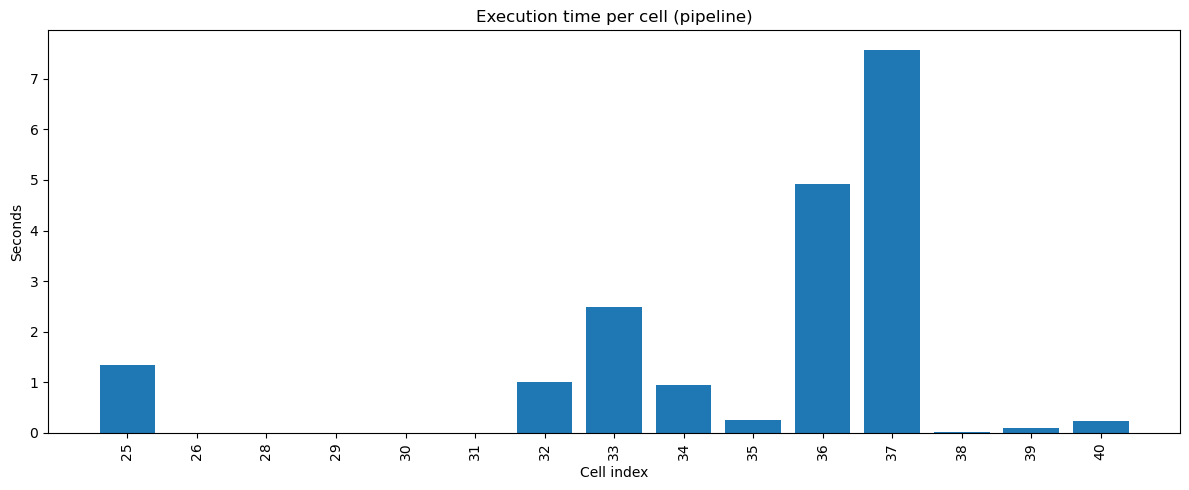

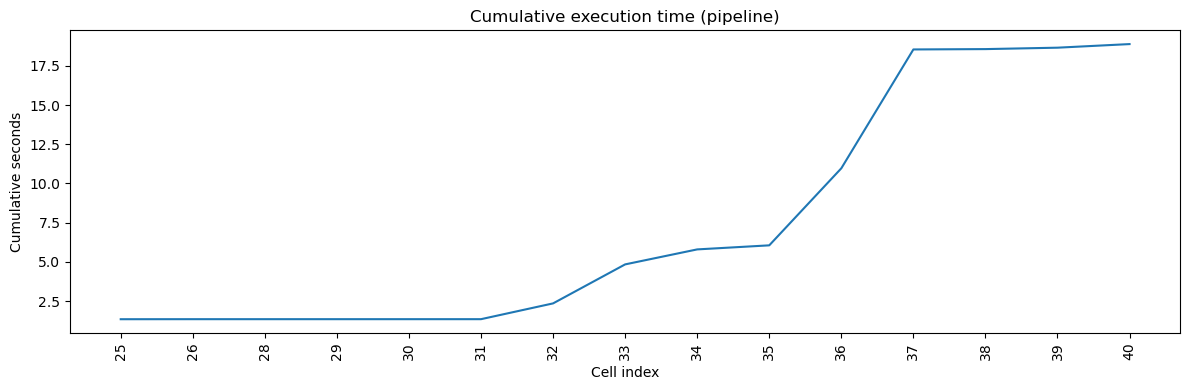

Total time: 18.885 seconds
CPU times: total: 484 ms
Wall time: 497 ms


In [18]:
%%time
# Bloco 17 — Sumário e visualização dos tempos coletados (__cell_timings)
#
# Objetivo:
# - Converter a lista __cell_timings (gerada pelo context manager __time_block) em um DataFrame
# - Exibir a tabela com os tempos por célula/bloco
# - Plotar:
#   (1) Barras com tempo por célula
#   (2) Linha com tempo acumulado (cumsum) ao longo do pipeline
# - Mostrar o tempo total somado
#
# Pré-requisito:
# - Que as células/blocos anteriores tenham sido executados e alimentado __cell_timings.
#
# Observações:
# - Este bloco assume que `display`, `plt` e `matplotlib` estão disponíveis no notebook.
#   Se não estiverem, importe:
#     from IPython.display import display
#     import matplotlib.pyplot as plt

import pandas as pd

# Se ainda não há medições (nenhum bloco medido), orienta o usuário
if len(__cell_timings) == 0:
    print("No timing data yet. Run the notebook cells above first, then re-run this cell.")
else:
    # Converte lista de dicionários em DataFrame e ordena por cell_index
    # (garante visualização na ordem do pipeline)
    df_t = (
        pd.DataFrame(__cell_timings)
        .sort_values("cell_index")
        .reset_index(drop=True)
    )

    # Garante tipo numérico para operações e plots
    df_t["seconds"] = df_t["seconds"].astype(float)

    # Exibe a tabela (útil para inspeção e auditoria do pipeline)
    display(df_t)

    # -----------------------------
    # Gráfico 1: tempo por célula
    # -----------------------------
    plt.figure(figsize=(12, 5))
    plt.bar(range(len(df_t)), df_t["seconds"])  # barras por posição (0..N-1)
    plt.xticks(
        range(len(df_t)),
        df_t["cell_index"].astype(str),         # rótulo no eixo x = índice da célula
        rotation=90                             # rotaciona para evitar sobreposição
    )
    plt.ylabel("Seconds")
    plt.xlabel("Cell index")
    plt.title("Execution time per cell (pipeline)")
    plt.tight_layout()  # ajusta margens automaticamente
    plt.show()

    # -----------------------------------------
    # Gráfico 2: tempo acumulado (cumulative)
    # -----------------------------------------
    # cumsum() mostra como o tempo total vai crescendo ao longo das células
    plt.figure(figsize=(12, 4))
    plt.plot(df_t["seconds"].cumsum().values)
    plt.xticks(
        range(len(df_t)),
        df_t["cell_index"].astype(str),
        rotation=90
    )
    plt.ylabel("Cumulative seconds")
    plt.xlabel("Cell index")
    plt.title("Cumulative execution time (pipeline)")
    plt.tight_layout()
    plt.show()

    # Tempo total do pipeline (soma das durações registradas)
    print(f"Total time: {df_t['seconds'].sum():.3f} seconds")
    

#### 11.5 Estimativa de Custo (USD): Execução do notebook por provedor

In [19]:
# Bloco — Estimativa de custo (USD) com base no tempo total do notebook
#
# Objetivo:
# - Garantir que o timestamp de início do notebook (__nb_start_time__) exista
# - Calcular o tempo total decorrido desde o início do notebook
# - Estimar custo proporcional ao tempo rodado, usando uma tabela simples de USD/hora
# - Montar e exibir um DataFrame com as estimativas por provedor
#
# Pré-requisitos:
# - `time` importado (import time)
# - `pd` disponível (import pandas as pd)
# - `display` disponível (Jupyter/IPython)
#
# Observações importantes:
# - Esses valores de USD/hora são placeholders: ajuste conforme sua instância/VM/região.
# - O cálculo assume cobrança linear por hora (sem arredondamentos por minuto, taxa mínima, etc.).
# - `__nb_start_time__` deve ser definido no topo do notebook para medir o "tempo total" real.

# Se a variável global de início não existir (ex.: célula inicial não foi executada),
# cria um valor agora e avisa que o tempo TOTAL pode estar subestimado.
if "__nb_start_time__" not in globals():
    __nb_start_time__ = time.perf_counter()
    print(
        "Aviso: __nb_start_time__ não estava definido. "
        "Cole/execute a célula de start no topo para medir o tempo TOTAL do notebook."
    )

# Tempo decorrido desde o início do notebook, em segundos
elapsed_seconds = time.perf_counter() - __nb_start_time__

# Converte para horas (base para multiplicar pelos preços por hora)
elapsed_hours = elapsed_seconds / 3600

# Tabela simples de preços por hora (USD/h).
# Ajuste conforme seu tipo de máquina / serviço / região.
hourly_rates_usd = {
    "AWS":   0.0416,
    "Azure": 0.3160,
    "GCP":   0.1340,
}

# Monta linhas para um DataFrame comparativo de custos por provedor
rows = []
for provider, usd_per_hour in hourly_rates_usd.items():
    # Custo proporcional ao tempo de execução (horas * USD/h)
    cost_usd = elapsed_hours * usd_per_hour

    rows.append({
        "provider": provider,
        "elapsed_seconds": round(elapsed_seconds, 2),            # tempo em segundos
        "elapsed_minutes": round(elapsed_seconds / 60, 2),       # tempo em minutos
        "usd_per_hour": usd_per_hour,                            # tarifa USD/h
        "estimated_cost_usd": round(cost_usd, 6),                # custo estimado (USD)
        # Custo escalado x1000 (útil p/ comparar em workloads maiores ou por 1000 execuções)
        "estimated_cost_usd_x1000": round(cost_usd * 1000, 2),
    })

# Cria DataFrame e ordena do maior custo para o menor
df_cost = pd.DataFrame(rows).sort_values("estimated_cost_usd", ascending=False)

# Resumo textual rápido
print(f"Tempo total estimado: {elapsed_seconds:.2f}s ({elapsed_seconds/60:.2f} min)")

# Exibe o DataFrame com as estimativas
display(df_cost)


Tempo total estimado: 19.68s (0.33 min)


,provider,elapsed_seconds,elapsed_minutes,usd_per_hour,estimated_cost_usd,estimated_cost_usd_x1000
1,Azure,19.68,0.33,0.3160,0.001727,1.73
2,GCP,19.68,0.33,0.1340,0.000732,0.73
0,AWS,19.68,0.33,0.0416,0.000227,0.23
